In [233]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 
import tangos as db
import flamingo_tangos as ft
import virial_scalings as vs 

from flamingo_analysis import internal_to_keV_cm2


from matplotlib.colors import LinearSegmentedColormap

n_col = 4
cmap = LinearSegmentedColormap.from_list("red_blue", ["red", "blue"], N=n_col)
colors = [cmap(i/n_col) for i in range(n_col)]

p.rc('axes', prop_cycle=p.cycler('color', [
    '#4477AA',  # steel blue
    '#EE6677',  # rose
    '#228833',  # forest green
    '#AA3377',  # plum
]))


def radial_ticks(relative=True):
    if relative:
        p.xlabel(r"$r / r_{\rm 200m}$")
    else:
        p.xlabel(r"$r/ \rm Mpc$")
    p.xlim(0.49,5.1)
    p.xticks([0.05, 0.1, 0.3, 1.0, 3.0], ['0.05', '0.1', '0.3', '1.0', '3.0'])

    if relative:
        p.axvline(1.0, color='lightgray', linestyle='-', zorder=0)
        p.axvline(2.0, color='#ddd', linestyle='-', zorder=0)
        

def mass_ticks():
    p.xticks([12.5, 13.0, 13.5, 14.0, 14.5], ['$10^{12.5}$', '$10^{13.0}$', '$10^{13.5}$', '$10^{14.0}$', '$10^{14.5}$'])
    p.xlabel(r"$M_{200\rm m} / {\rm M_\odot}$")

def upper_axis():
    p.gca().xaxis.set_ticks_position('top')
    p.gca().xaxis.set_label_position('top')
    p.gca().xaxis.set_ticks_position('both')

def lower_axis():
    p.gca().xaxis.set_ticks_position('bottom')
    p.gca().xaxis.set_label_position('bottom')
    p.gca().xaxis.set_ticks_position('both')

def upper_radial_axis(relative=True):
    upper_axis()
    radial_ticks(relative=relative)

def lower_radial_axis(relative=True):
    lower_axis()
    radial_ticks(relative=relative)

def lower_mass_axis():
    lower_axis()
    mass_ticks()

db.init_db('data.db')
db.all_simulations()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[<Simulation("L0200N0360_HYDRO_FIDUCIAL")>,
 <Simulation("L0200N0360_HYDRO_JETS_STRONGER_AGN")>,
 <Simulation("L0200N0360_HYDRO_JETS")>,
 <Simulation("L0200N0360_HYDRO_WEAK_AGN")>,
 <Simulation("L0200N0360_HYDRO_STRONGEST_AGN")>,
 <Simulation("L0200N0720_HYDRO_FIDUCIAL")>]

Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


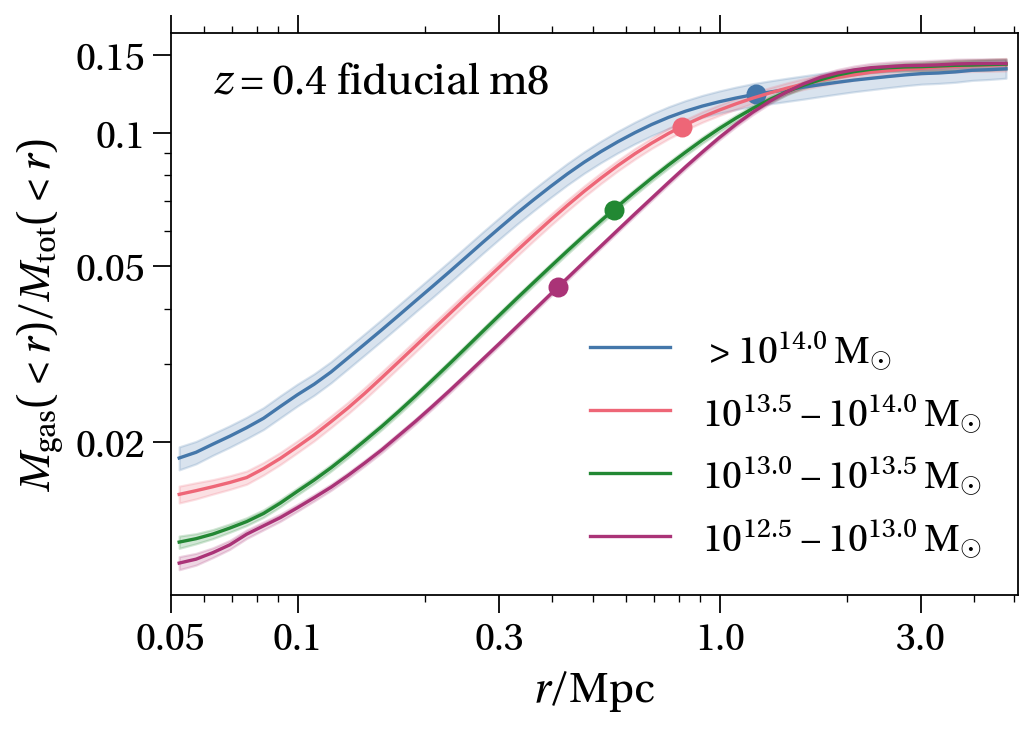

In [234]:
fa.make_profile_plots('mass_enclosed', particle='ratio', tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", with_legend=True, mark_r200=True, panels=('absolute',))

p.xlabel(r'$r / {\rm Mpc}$')
p.ylabel(r"$M_{\rm gas}(<r) / M_{\rm tot}(<r)$")
p.yticks([0.02, 0.05, 0.1, 0.15], ['0.02', '0.05', '0.1', '0.15'])
p.xlim(0.05,5.0)
p.text(0.05, 0.95, "$z=0.4$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
p.title("")
p.savefig('profiles_absolute_with_r200m.pdf', bbox_inches='tight')
lower_radial_axis(relative=False)


### Cross-check plot

Ensure that the baryon density returns to the cosmic mean at large radii

Plotting density_from_mass() profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


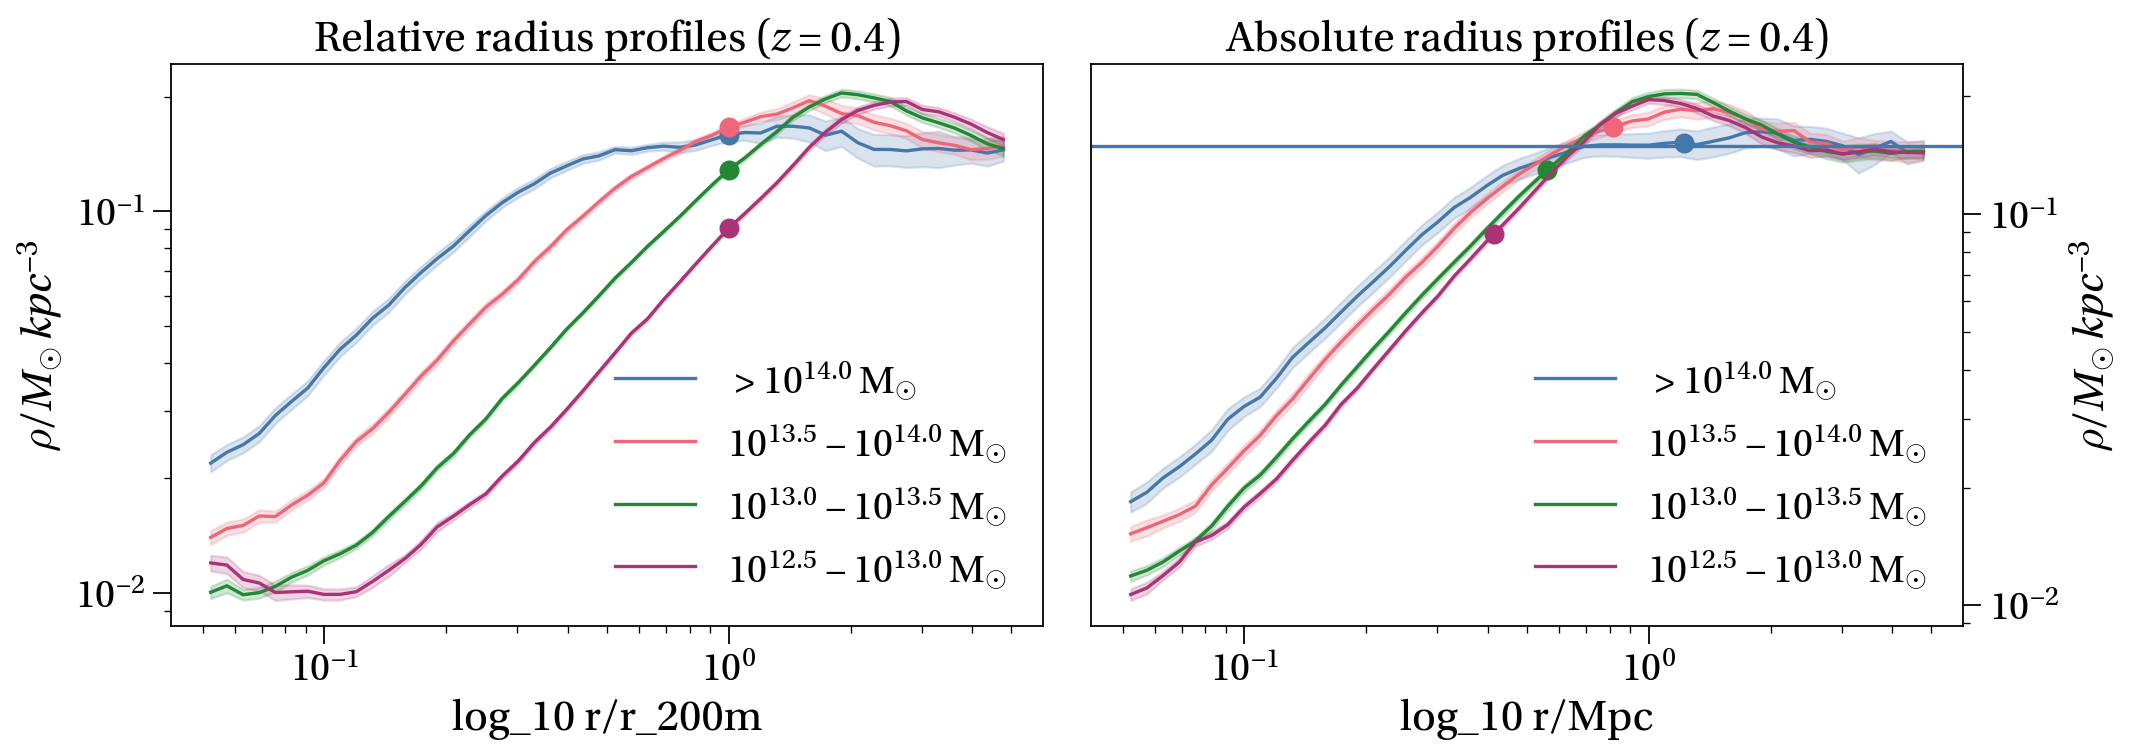

In [127]:
fa.make_profile_plots('density_from_mass()', particle='ratio', tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL", newfig=True, mark_r200=True)
p.axhline(0.14924)

# $\dot{f}_{\rm gas}$ decomposition plot

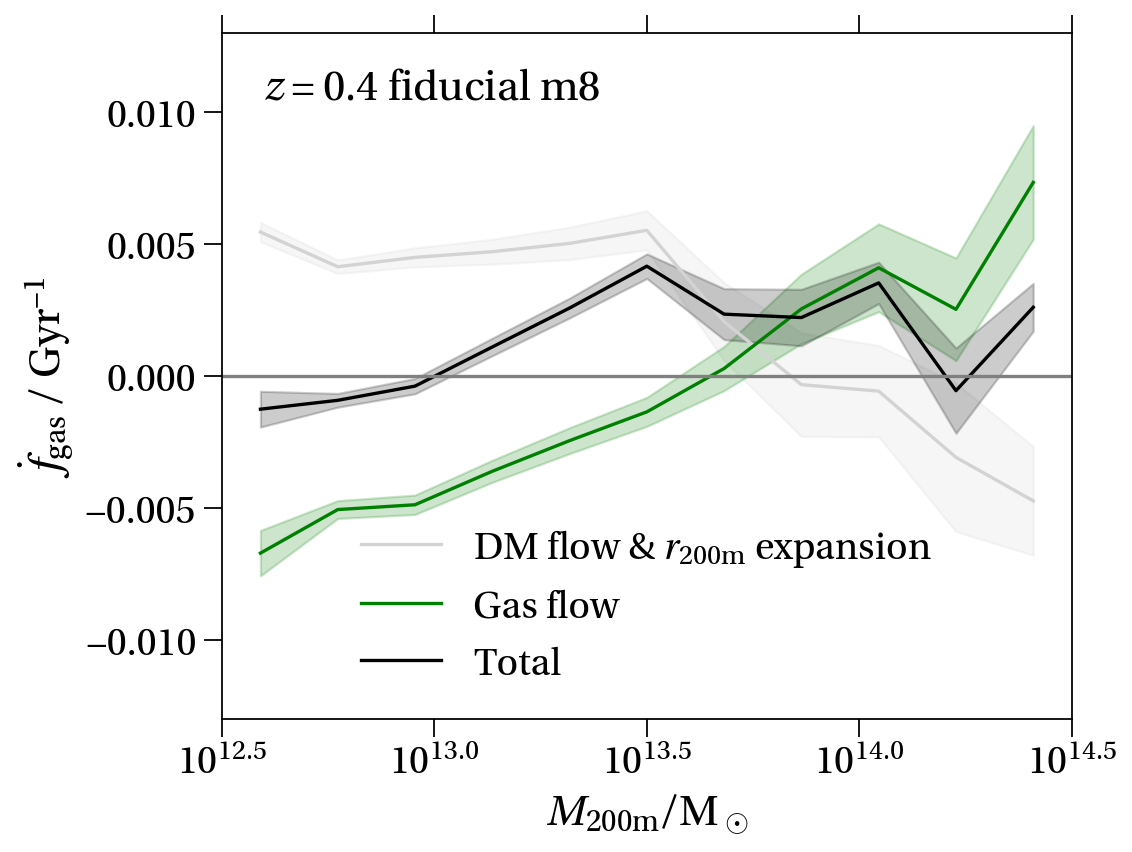

In [235]:
# NB minus sign due to mdot being outflow rather than inflow directed
ts_name = '%720%/%4.hdf5'
gas_term = '-1e9*at(0.0, gas_mdot_r200m_relative)/at(0.0, all_mass_enclosed_r200m_relative)'
dm_term = '1e9*at(0.0, all_mdot_r200m_relative)*at(0.0, gas_mass_enclosed_r200m_relative)/at(0.0, all_mass_enclosed_r200m_relative)**2'
r200_term = '1e9*r200m_dot()*dfgas_dr()'
num_bins = 11

p.figure()
fa.make_binned_by_mass_plot(f"({dm_term}) + ({r200_term})", plot_kwargs={'color': 'lightgray', 'label': r'DM flow & $r_{\rm 200m}$ expansion'}, ts_name = ts_name, 
                            error_range='uncertainty', use_band=True, num_bins=num_bins)
fa.make_binned_by_mass_plot(gas_term, ts_name = ts_name, plot_kwargs={'color': 'green', 'label': 'Gas flow'}, error_range='uncertainty', 
                            use_band=True, num_bins=num_bins)


total = f"({gas_term}) + ({dm_term}) + ({r200_term})"
fa.make_binned_by_mass_plot(total, plot_kwargs={'color': 'black', 'label': 'Total'}, ts_name = ts_name, error_range='uncertainty', use_band=True,
                            num_bins=num_bins)
p.title("")
p.ylabel(r"$\dot{f}_{\rm gas}$ / Gyr$^{-1}$")
lower_mass_axis()
p.legend(loc='lower center')
p.text(0.05, 0.95, "$z=0.4$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
p.axhline(0.0, color='gray', linestyle='-')
p.ylim(-0.013, 0.013)
p.savefig('fgas_evolution_breakdown.pdf', bbox_inches='tight')


### Cross-check

Should get qualitatively the same from a discrete time-differencing version of the same terms

/Users/app/Science/flamingo/venv/lib/python3.13/site-packages/tangos/live_calculation/builtin_functions/arithmetic.py:93: RuntimeWarning: divide by zero encountered in divide
  result = op(v1,v2)
/Users/app/Science/flamingo/venv/lib/python3.13/site-packages/tangos/live_calculation/builtin_functions/arithmetic.py:93: RuntimeWarning: invalid value encountered in divide
  result = op(v1,v2)


(-0.013, 0.013)

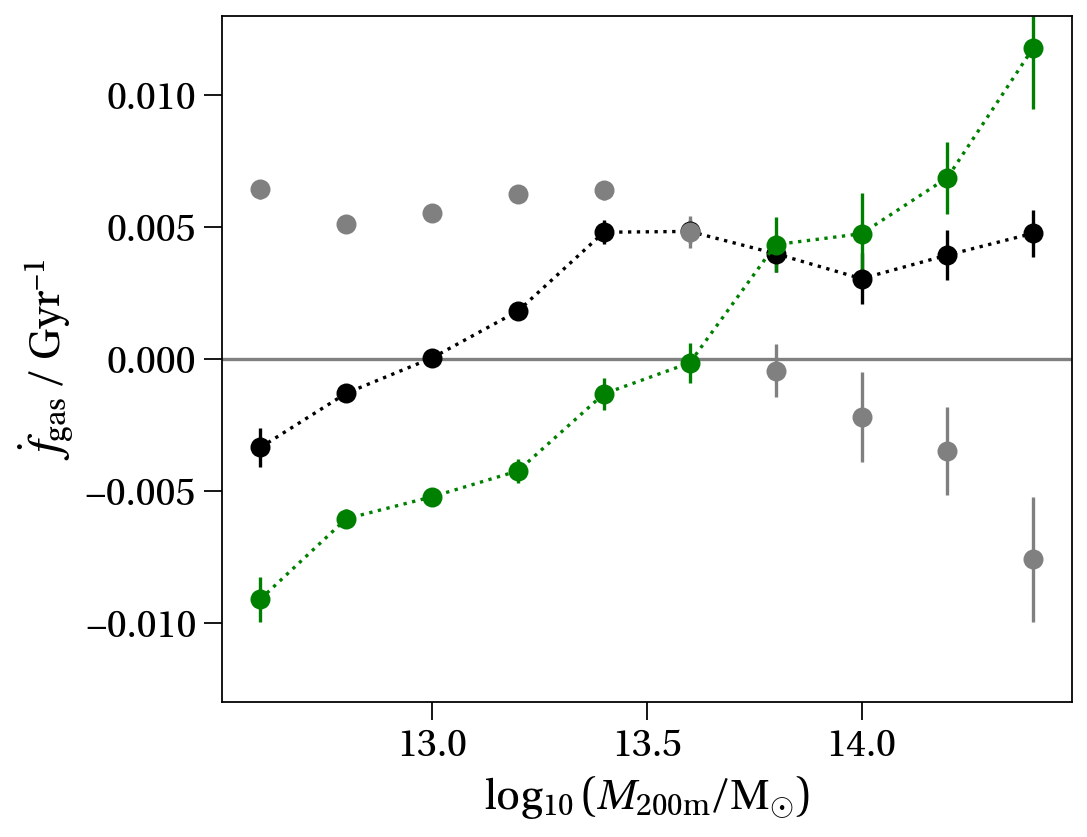

In [236]:
# DISCRETE TIME VERSION of the gas fraction evolution breakdown, as a cross-check

ts_name = '%720%/%4.%'
delta_t_gyr = db.get_timestep(ts_name).time_gyr - db.get_timestep(ts_name).previous.time_gyr

gas_mass_enc = 'at(log10(r200m)-3.0, gas_mass_enclosed)'
delta_gas_mass_enc = f'{gas_mass_enc} - earlier(1).at(later(1).log10(r200m)-3.0, gas_mass_enclosed)'
delta_gas_term = f'({delta_gas_mass_enc}) / at(0.0, dm_mass_enclosed_r200m_relative)'

delta_fgas = f'at(0.0, gas_mass_enclosed_r200m_relative/dm_mass_enclosed_r200m_relative) - earlier(1).at(0.0, gas_mass_enclosed_r200m_relative/dm_mass_enclosed_r200m_relative)'

dm_mass_enc = 'at(log10(r200m)-3.0, dm_mass_enclosed)'
delta_dm_mass_enc = f'earlier(1).at(later(1).log10(r200m)-3.0, dm_mass_enclosed) - {dm_mass_enc}'
delta_dm_term = f'({delta_dm_mass_enc}) * earlier(1).(at(0.0, gas_mass_enclosed_r200m_relative) / at(0.0, dm_mass_enclosed_r200m_relative)) / at(0.0, dm_mass_enclosed_r200m_relative)'

delta_r200_term = 'at(log10(r200m)-3.0, earlier(1).gas_mass_enclosed)/at(log10(r200m)-3.0, earlier(1).dm_mass_enclosed) - at(log10(earlier(1).r200m)-3.0, earlier(1).gas_mass_enclosed)/at(log10(earlier(1).r200m)-3.0, earlier(1).dm_mass_enclosed)'

# all_terms = f'({delta_gas_term}) + ({delta_dm_term} + {delta_r200_term})'  # -- can verify this gives same as delta_fgas, by construction of discrete derivative-like terms

fa.make_binned_by_mass_plot(f'({delta_fgas}) / {delta_t_gyr}', ts_name = ts_name, plot_kwargs={'color': 'black', 'linestyle': ':'}, num_bins = 10, error_range='uncertainty')
fa.make_binned_by_mass_plot(f'({delta_dm_term} + {delta_r200_term}) / {delta_t_gyr}', ts_name = ts_name, plot_kwargs={'color': 'gray'}, num_bins = 10, error_range='uncertainty')
fa.make_binned_by_mass_plot(f'({delta_gas_term}) / {delta_t_gyr}', ts_name = ts_name, plot_kwargs={'color': 'green', 'linestyle': ':'}, num_bins = 10, error_range='uncertainty')

p.title("")
p.ylabel(r'$\dot{f}_{\rm gas}$ / Gyr$^{-1}$')
p.xlabel(r'$\log_{10}(M_{\rm 200m} / {\rm M}_{\odot})$')
p.axhline(0.0, color='gray', linestyle='-')
p.ylim(-0.013, 0.013)

# Main flow rate plot

In [240]:
from matplotlib.lines import Line2D

def outflow_inflow_legend(mgas=None):
    custom_lines = [Line2D([0], [0], color='black', linewidth=1),
                    Line2D([0], [0], color='black', linewidth=1, linestyle='--')]
    labels = ['Outflow', 'Inflow']

    if mgas is not None:
        import flow_orientation # just for _sci_latex
        labels.append(rf"$10^{{{np.log10(mgas):.1f}}} \, {{\rm M}}_\odot$")
        print(labels)
        custom_lines += [Line2D([0], [0], color='black', marker='x', linestyle='None')]
    ax = p.gca()

    existing_legend = ax.get_legend()
    if existing_legend is not None:
        ax.add_artist(existing_legend)
    
    if existing_legend is not None:
        ax.figure.canvas.draw()
        bbox_axes = existing_legend.get_window_extent().transformed(ax.transAxes.inverted())
        p.legend(
            custom_lines, labels,
            loc='lower right',
            bbox_to_anchor=(bbox_axes.x0, bbox_axes.y0),
            borderaxespad=0.0
        )
    else:
        p.legend(
            custom_lines, labels,
            loc='lower right',
            frameon=True,
            facecolor='white',
            framealpha=1.0,
            edgecolor='none'
        )

def make_final_flow_plot(particle='gas', tsnum=4, box="L0200N0720_HYDRO_FIDUCIAL"):
    

    fa.make_profile_plots('mdot_outflow', particle=particle, tsnum=tsnum, box=box, panels=('relative',), newfig=False)

    if particle == 'gas':
        redshift = db.get_timestep(f'%720%/%{tsnum}.hdf5').redshift
        p.text(0.05, 0.95, rf"$z={redshift:.1f}$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
        p.text(0.95, 0.95, "Gas", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='right')
        outflow_inflow_legend()
        p.ylim(0.15*6e1, 0.15*6e4)
    else:
        p.text(0.95, 0.95, "DM", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='right')
        p.legend(loc='best')
        p.ylim(7e1, 6e4)

    fa.make_profile_plots('mdot_inflow', particle=particle, tsnum=4, box=box, 
                        plot_kwargs={'linestyle':'--'}, newfig=False, panels=('relative', ))
    

    

    particle_cased = 'gas' if particle=='gas' else 'DM'
    p.ylabel(r"$\dot{M}_{\rm {"+particle_cased+r"}}(r) \, / \, {\rm M}_{\odot}\,{\rm yr}^{-1}$")
    p.title("")
    

    p.gca().yaxis.set_ticks_position('both')
    
    
    p.xlim(0.05,5.0)

Plotting mdot_outflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mdot_inflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mdot_outflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mdot_inflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


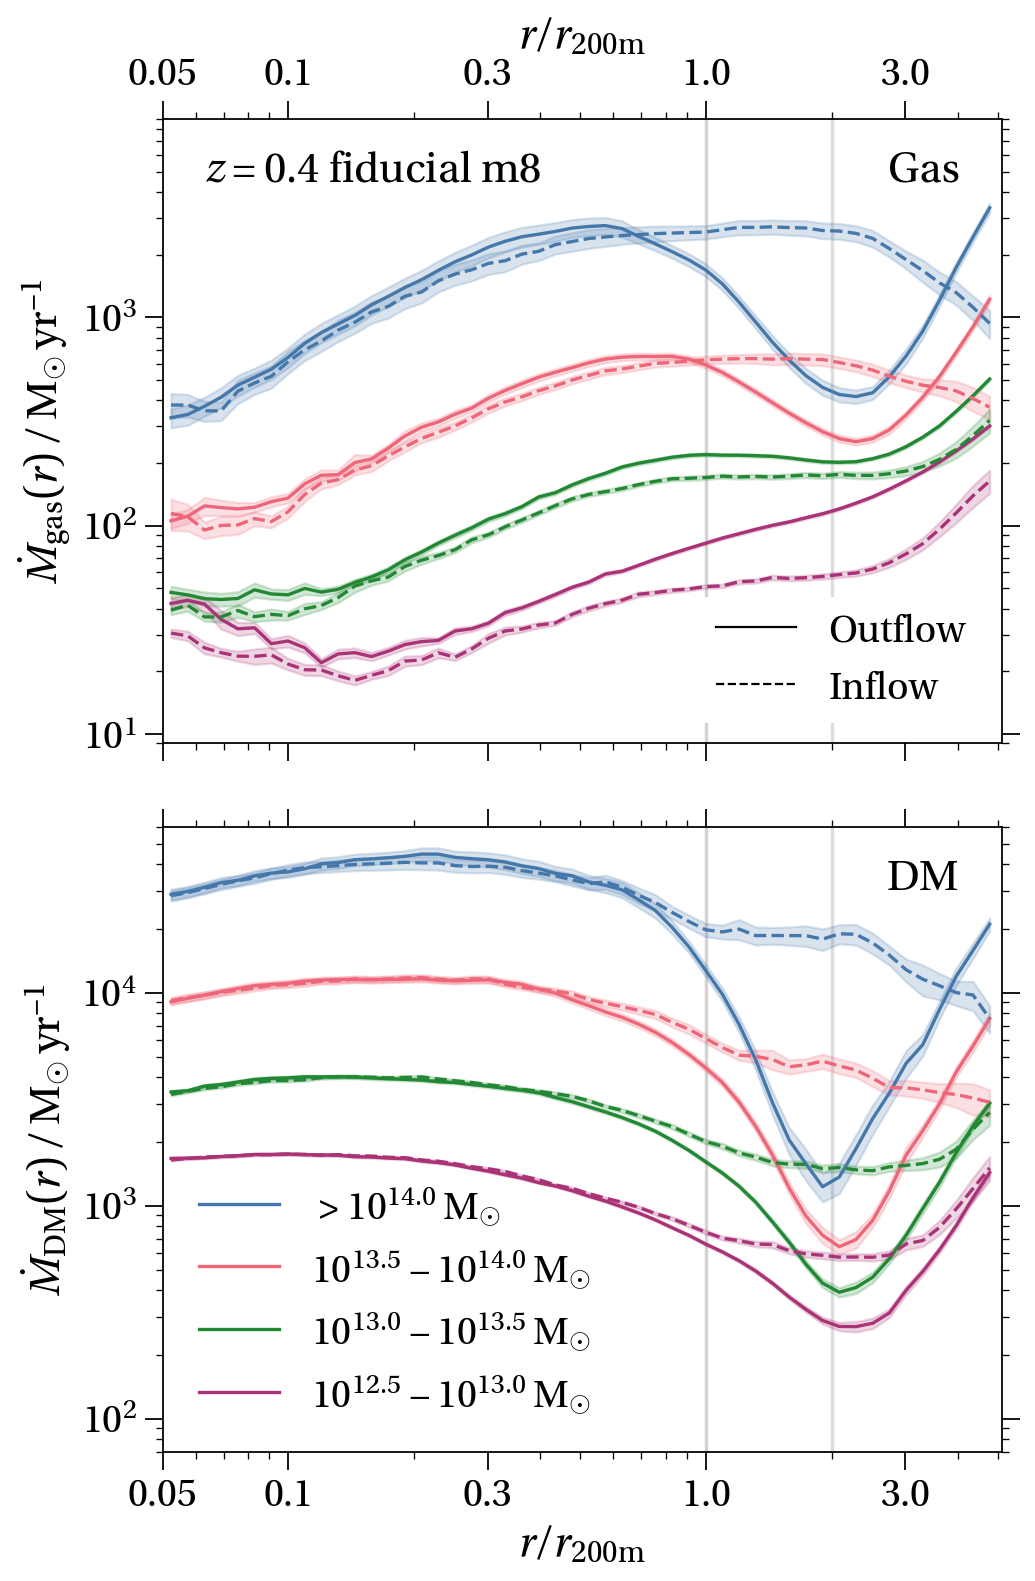

In [241]:
box="L0200N0720_HYDRO_FIDUCIAL"

p.figure(figsize=(6.9, 5.2*2))
p.subplot(2,1,1)
make_final_flow_plot(particle='gas', tsnum=4, box=box)
upper_radial_axis()

p.subplot(2,1,2)
make_final_flow_plot(particle='dm', tsnum=4, box=box)
lower_radial_axis()

p.tight_layout()
p.savefig("outflow_inflow_profiles.pdf", bbox_inches='tight')


Plotting entropy_outflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting entropy_inflow profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting entropy_generation profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


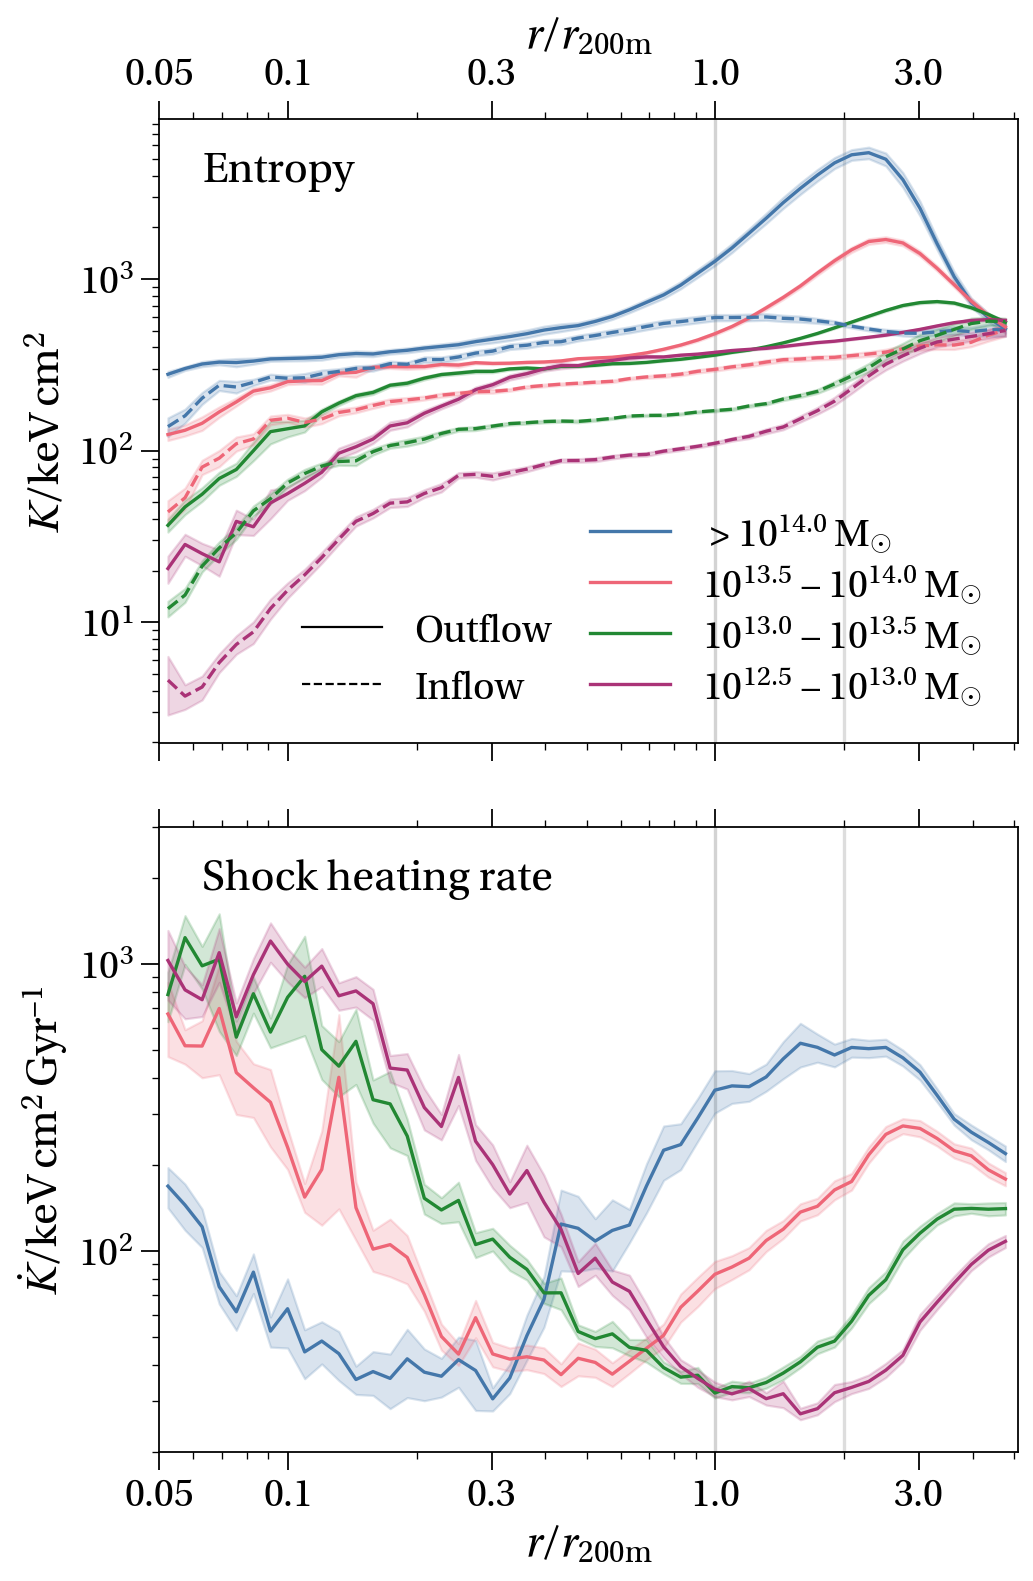

In [281]:
box = "L0200N0720_HYDRO_FIDUCIAL"
#box = "L0200N0360_HYDRO_JETS_STRONGER_AGN"
#box = "L0200N0360_HYDRO_FIDUCIAL"
#box = "L0200N0360_HYDRO_STRONGEST_AGN"
mass_enc_point = 5e10

p.figure(figsize=(6.9, 5.2*2))
p.subplot(211)
fa.make_profile_plots('entropy_outflow', particle='gas', tsnum=4, box=box, 
                        plot_kwargs={'linestyle':'-'}, newfig=False, panels=('relative', ),
                        rescale = internal_to_keV_cm2, 
                        weight_by = 'mdot_outflow')
p.legend(loc='lower right', labelspacing=0.2)
fa.make_profile_plots('entropy_inflow', particle='gas', tsnum=4, box=box, 
                        plot_kwargs={'linestyle':'--'}, newfig=False, panels=('relative', ),
                        rescale = internal_to_keV_cm2, weight_by = 'mdot_inflow')
outflow_inflow_legend()
p.ylabel(r"$K / \mathrm{keV\,cm^2}$")
p.text(0.05, 0.95, "Entropy", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
p.title("")
upper_radial_axis()
p.subplot(212)
p.text(0.05, 0.95, "Shock heating rate", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
fa.make_profile_plots('entropy_generation', particle='gas', tsnum=4, box=box, 
                        plot_kwargs={'linestyle':'-'}, newfig=False, panels=('relative', ),
                        rescale = 1000.*internal_to_keV_cm2)
p.ylabel(r"$\dot{K} / \mathrm{keV\,cm^2\,Gyr^{-1}}$")
p.title("")
lower_radial_axis()
p.tight_layout()
#p.yticks([0.1, 1.0], ['0.1', '1.0'])
p.ylim(0.02e3, 3.0e3)
p.savefig("entropy_and_generation_profiles.pdf", bbox_inches='tight')


# Energy rate plot

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vk/zg9_2k_512l3syhc8kdzkzwm0000gp/T/ipykernel_59512/32963698.py:8: SyntaxWarning: invalid escape sequence '\s'
  label = r'$z=0.4$ jets-4$\sigma$ m9; $r=100\,{\rm kpc}$'


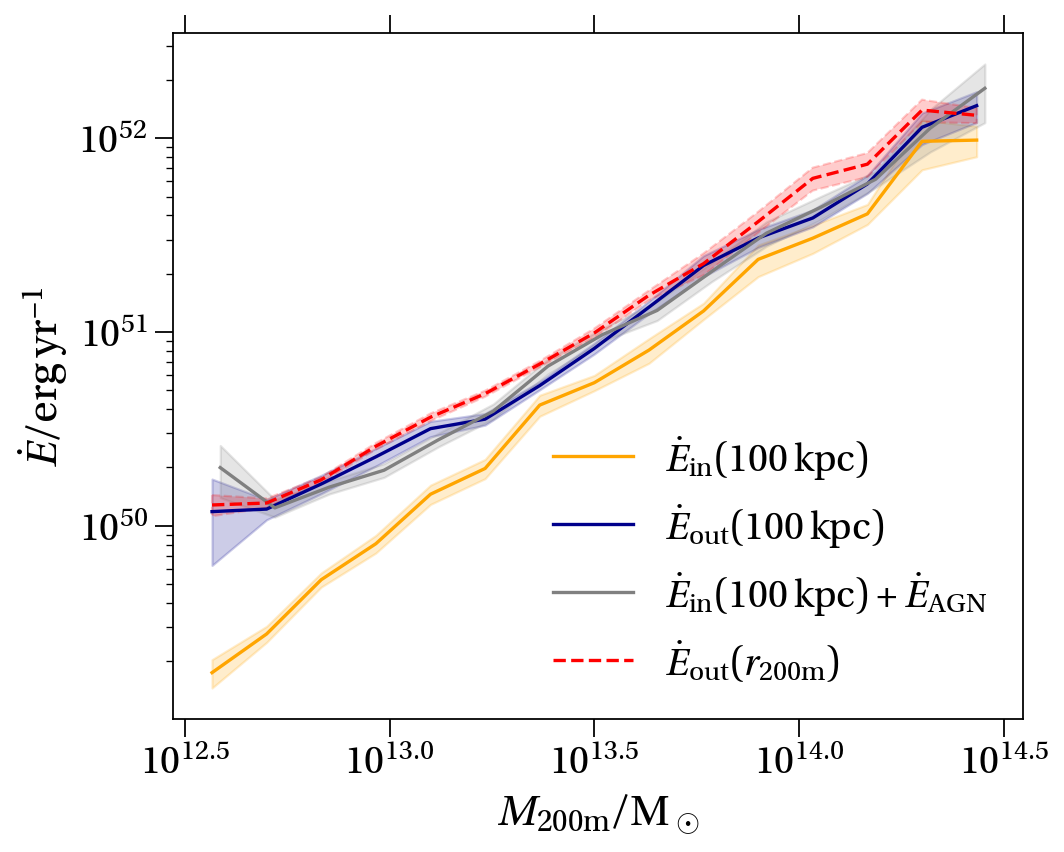

In [259]:
ts_name = '%720%/%4.%'
radius = 0.1
label = r''

"""
ts_name = '%360%JETS_STRONGER%/%4.%'
radius = 0.10
label = r'$z=0.4$ jets-4$\sigma$ m9; $r=100\,{\rm kpc}$'
"""

fa.make_binned_by_mass_plot(f'1e-6*at(log10({radius}), gas_energy_inflow)',
                            ts_name=ts_name,
                            plot_kwargs={'color': 'orange'},
                            use_band=True)

fa.make_binned_by_mass_plot(f'1e-6*at(log10({radius}), gas_energy_outflow)',
                            ts_name=ts_name,
                            use_band=True, 
                            plot_kwargs={'color': 'darkblue'}
                            )

fa.make_binned_by_mass_plot(f'2.7e52*0.0102*InclusiveSphere_30kpc_MostMassiveBlackHoleAccretionRate + 1e-6*at(log10({radius}), gas_energy_inflow)', 
                            ts_name=ts_name, 
                            plot_kwargs={'color': 'grey'},
                            use_band=True, x_offset=0.02)

fa.make_binned_by_mass_plot(f'1e-6*at(0.0, gas_energy_outflow_r200m_relative)',
                            ts_name=ts_name,
                            use_band=True, 
                            plot_kwargs={'color': 'red', 'linestyle': '--'},
                            )

p.semilogy()
p.title("")
lower_mass_axis()
p.ylabel(r"$\dot{E} / {\rm erg\,yr^{-1}}$")
fa.legend([r'$\dot{E}_{\rm in}(100\, {\rm kpc})$', None, 
           r'$\dot{E}_{\rm out}(100\, {\rm kpc})$',  None, 
           r'$\dot{E}_{\rm in}(100\, {\rm kpc}) + \dot{E}_{\rm AGN}$', None, 
           r"$\dot{E}_{\rm out}(r_{200\rm m})$"], loc='lower right')
p.text(0.05, 0.95, label, transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')



p.savefig("energy_inflow_outflow_vs_mass.pdf", bbox_inches='tight')

### Cross-check: what are the cooling times at this radius?

It seems like cooling is playing no real role in this, otherwise inflow + AGN feedback would need
to be greater than the outflow energies.

However, the situation is a bit more subtle. First, it *is* true that the typical parcel of gas at these radii has very long cooling time.


Text(0, 0.5, '$t_{\\rm cool} / {\\rm Gyr}$')

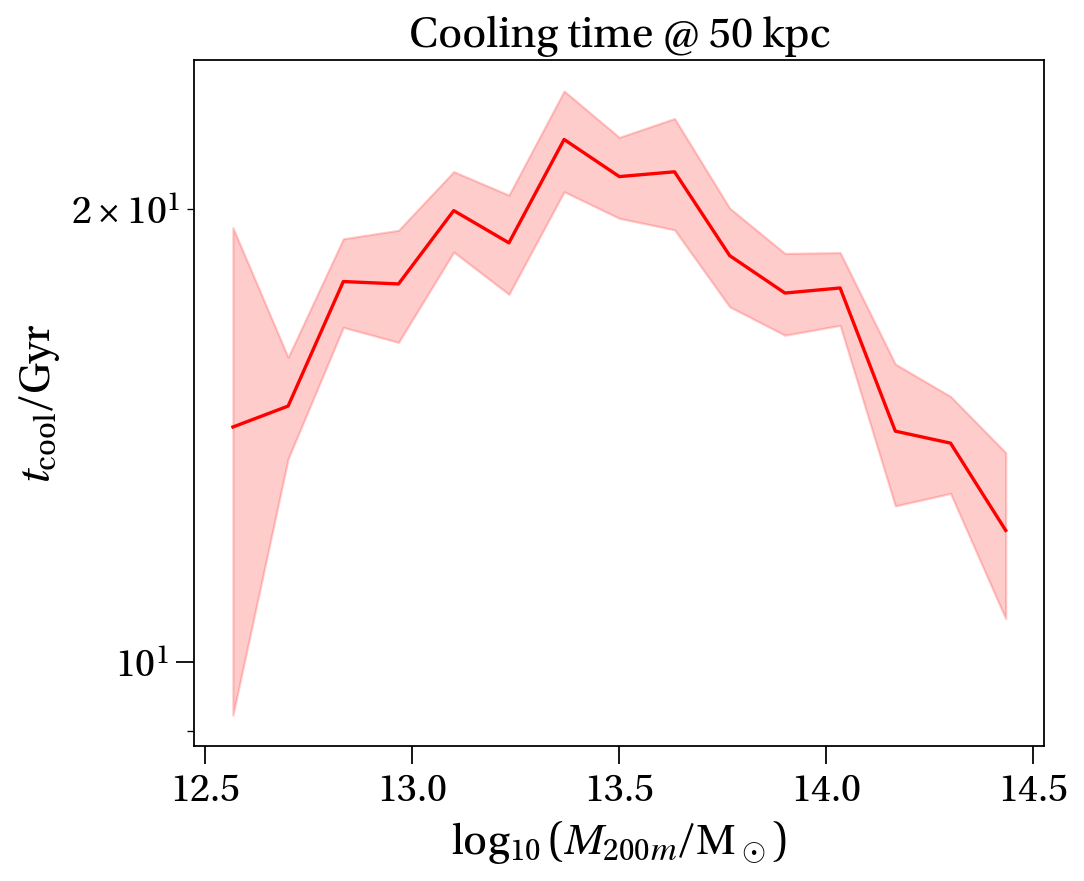

In [100]:
fa.make_binned_by_mass_plot(f'at(-1.3, gas_cooltime)', ts_name=ts_name, 
                            plot_kwargs={'color': 'red'}, use_band=True)
p.semilogy()
p.title("Cooling time @ 50 kpc")
p.xlabel(r"$\log_{10}(M_{200m} / {\rm M_\odot})$")
p.ylabel(r"$t_{\rm cool} / {\rm Gyr}$")

However, this does not mean that cooling is completely unimportant.

We define a cooling significance ratio as $\langle r / |v_r| t_{\rm cool} \rangle$. If this is >~1, cooling plays
a dynamically significant role. If it is << 1, cooling plays no significant role in the inflow
at the given radius.

In [98]:
def cooling_significance_plot(radius=0.1, relative=True, ts_name='%720%/%4.%'):
    import pynbody 
    conversion_factor = (5./3.)/(pynbody.units.Unit("km Gyr s^-1").in_units("kpc")) 
    # 5./3 is because we stored cooling time as u/\dot{E}, 
    # but expect ~const pressure cooling => we want enthalpy not energy

    log10_radius = np.log10(radius)
    if relative:
        radius_kpc = f'({radius}*r200m)'
        tag = '_r200m_relative'
        radius_title = f'{radius} r200m'
    else:
        radius_kpc = f'{radius*1000}'
        tag = ''
        radius_title = f'{radius*1000} kpc'

    fa.make_binned_by_mass_plot(f'{radius_kpc}/({-conversion_factor}*at({log10_radius}, gas_vr_inflow{tag})*at({log10_radius}, gas_cooltime_inflow{tag}))',
                                ts_name=ts_name,
                                plot_kwargs={'color': 'red'},
                                use_band=True,
                                weight_property_name=f'at({log10_radius}, gas_mdot_inflow{tag})')
    
    fa.make_binned_by_mass_plot(f'{radius_kpc}/({conversion_factor}*at({log10_radius}, gas_vr_outflow{tag})*at({log10_radius}, gas_cooltime_outflow{tag}))',
                                ts_name=ts_name,
                                plot_kwargs={'color': 'blue'},
                                use_band=True,
                                weight_property_name=f'at({log10_radius}, gas_mdot_outflow{tag})')
    fa.legend(['Inflow', None, 'Outflow'], loc='lower right')
    p.axhline(1.0, color='gray', linestyle='--')

    p.title(f"Cooling significance measure @ {radius_title}")
    p.ylabel(r"$\langle r / (t_{\rm cool} |v_r|) \rangle$ ")
    p.xlabel(r"$\log_{10}(M_{200m} / {\rm M_\odot})$")
    p.semilogy()


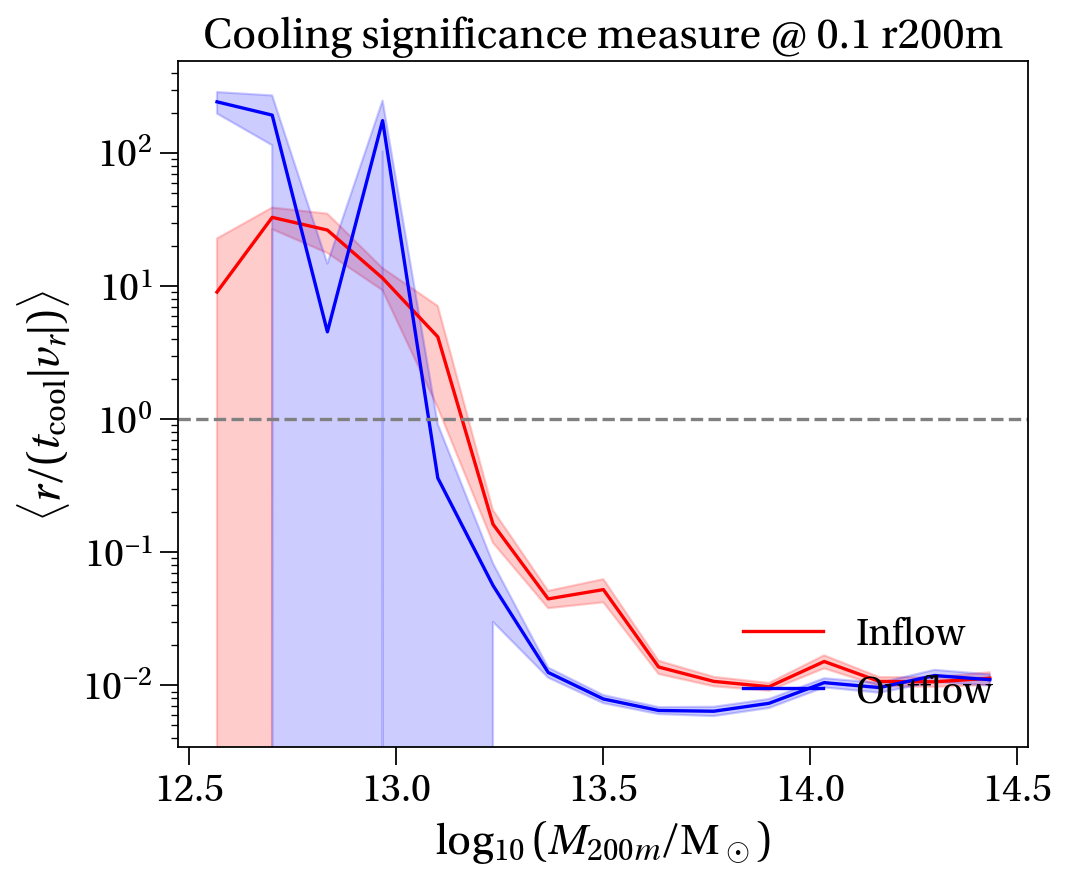

In [104]:
cooling_significance_plot(radius=0.1, relative=True)

### Cross-check: what about the gravitational potential?

How is energy 'conserved' from 100kpc to r200m? Of course the gravitational potential must be playing 
a role, so where's it gone in the main plot above which neglects gravity entirely? Here's the comparison again but now including the gravitational energy, with the potential chosen to be zero at the centre of each halo.

/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_tangos.py:768: RuntimeWarning: divide by zero encountered in divide
  t1 = G*mass_enclosed_inner_edge*(1./r_inner - 1./r_outer)
/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_tangos.py:768: RuntimeWarning: invalid value encountered in multiply
  t1 = G*mass_enclosed_inner_edge*(1./r_inner - 1./r_outer)


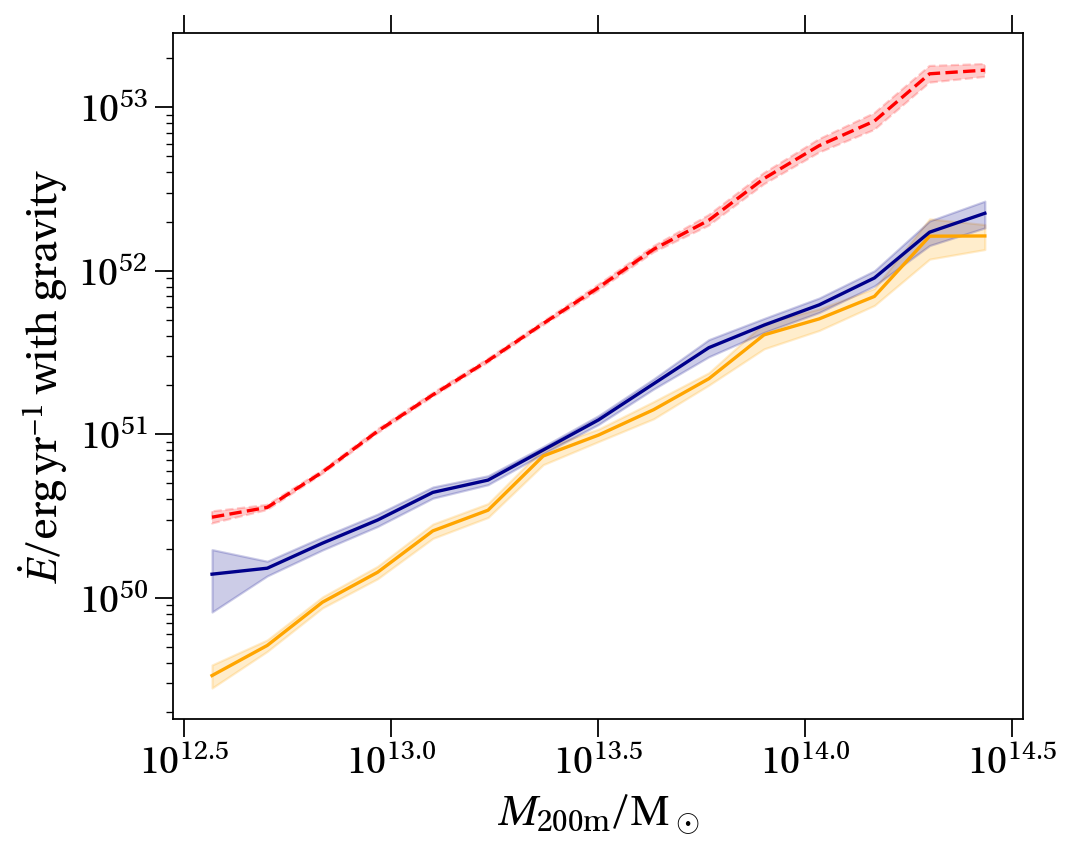

In [264]:

fa.make_binned_by_mass_plot(f'1e-6*at(log10({radius}), gas_energy_with_potential_inflow())',
                            ts_name=ts_name,
                            plot_kwargs={'color': 'orange'},
                            use_band=True)

fa.make_binned_by_mass_plot(f'1e-6*at(log10({radius}), gas_energy_with_potential_outflow())',
                            ts_name=ts_name,
                            use_band=True, 
                            plot_kwargs={'color': 'darkblue'}
                            )

fa.make_binned_by_mass_plot(f'1e-6*at(log10(r200m)-3.0, gas_energy_with_potential_outflow())',
                            ts_name=ts_name,
                            use_band=True, 
                            plot_kwargs={'color': 'red', 'linestyle': '--'},
                            )

p.semilogy()
p.title("")
p.ylabel(r"$\dot{E} / {\rm erg\,yr^{-1}}$ with gravity")
lower_mass_axis()

So in fact the gravitational potential energy vastly dominates over the other types of energy!

This is only possible if outflows are basically powered by buoyancy. If they had exactly neutral buoyancy, then the gravitational potential energy would be completely irrelevant. If (as we think is the case) they are actually somewhat buoyant, the effects of gravity would be *negative*. In reality, energy added by gravity as they outflow is probably lost to ram pressure/turbulence and they rise in some kind of equilibrium.

For the paper, let's get some handy values:

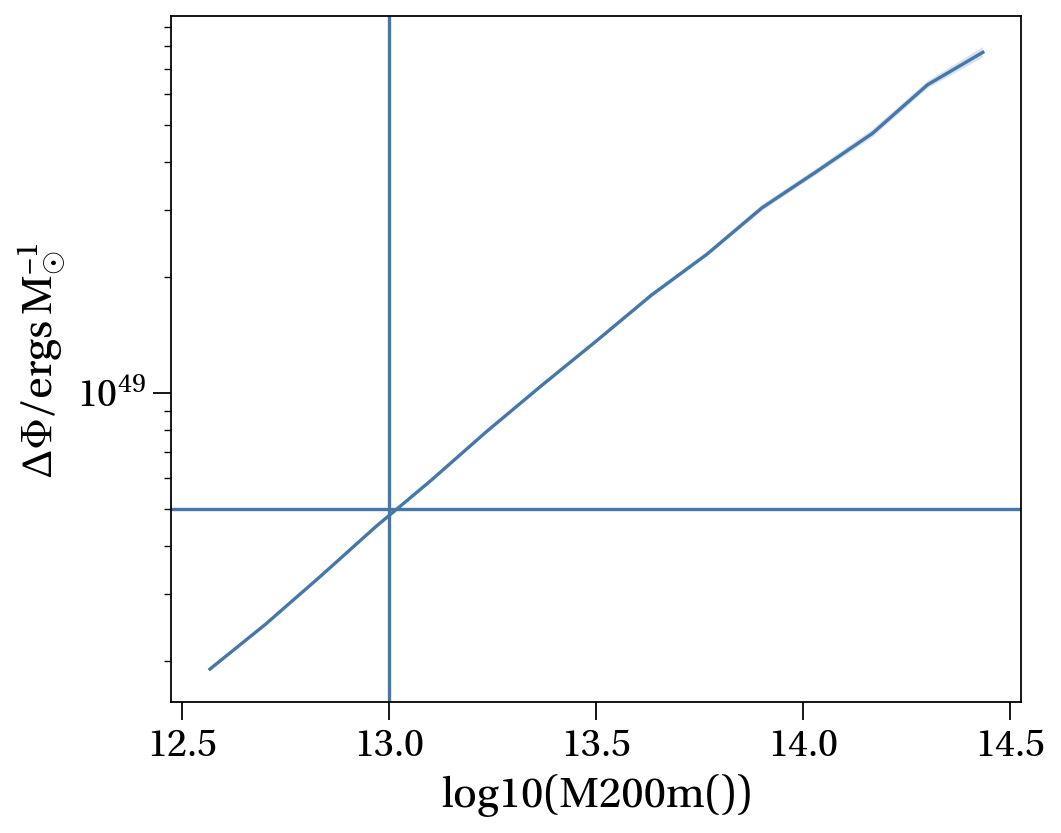

In [277]:
fa.make_binned_by_mass_plot(f'at(log10(r200m)-3.0, all_potential_from_mass())-at(-1.0, all_potential_from_mass())',
                            ts_name=ts_name,
                            use_band=True, 
                            )
p.semilogy()

p.title("")
p.ylabel(r"$\Delta \Phi/{\rm ergs\, M_{\odot}^{-1}}$ ")
p.axvline(13.0)
p.axhline(5e48)

# Entropy summary plot

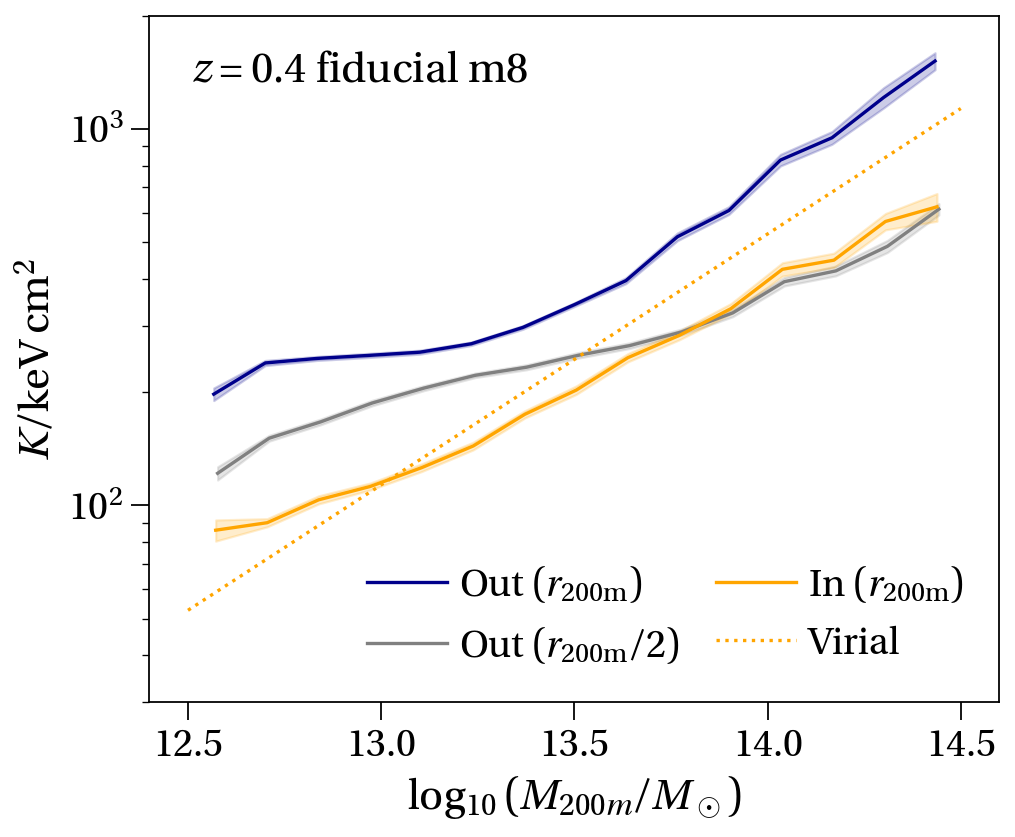

In [144]:
ts = '%360%WEAK%/%4.%'


"""fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(-1.3, gas_entropy_outflow)', 
                                plot_kwargs={'color': 'lightblue'},
                                ts_name=ts,
                                weight_property_name=f'at(-1.3, gas_mdot_outflow)',
                                x_offset=0.01, use_band=True,
                                )
"""


fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(0, gas_entropy_outflow_r200m_relative)', 
                                plot_kwargs={'color': 'darkblue'},
                                ts_name=ts, use_band=True, 
                                weight_property_name=f'at(0, gas_mdot_outflow_r200m_relative)'
                                )

fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(-0.3, gas_entropy_outflow_r200m_relative)', 
                                plot_kwargs={'color': 'grey'},
                                ts_name=ts,
                                weight_property_name=f'at(-0.3, gas_mdot_outflow_r200m_relative)',
                                x_offset=0.01, use_band=True,
                                )


fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(0, gas_entropy_inflow_r200m_relative)', 
                                plot_kwargs={'color': 'orange'},
                                ts_name=ts, use_band=True,
                                weight_property_name=f'at(0, gas_mdot_inflow_r200m_relative)',
                                x_offset=0.005,
                                )

p.text(0.05, 0.95, "$z=0.4$ fiducial m8", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')

p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
p.ylabel(r"$K / \mathrm{keV\,cm^2}$")


p.title("")
fa.plot_entropy_guide()
fa.legend([r'Out ($r_{\rm 200m}$)', None, 
          r'Out ($r_{\rm 200m}/2$)', None, 
          r'In ($r_{\rm 200m}$)', None, 
          'Virial'], loc='lower right', ncol=2, columnspacing=0.9, handletextpad=0.3)
p.semilogy()
p.ylim(3e1, 2e3)
p.yticks([100, 1000], ['$10^2$', '$10^3$'])
p.savefig('entropy_inflow_outflow.pdf', bbox_inches='tight')

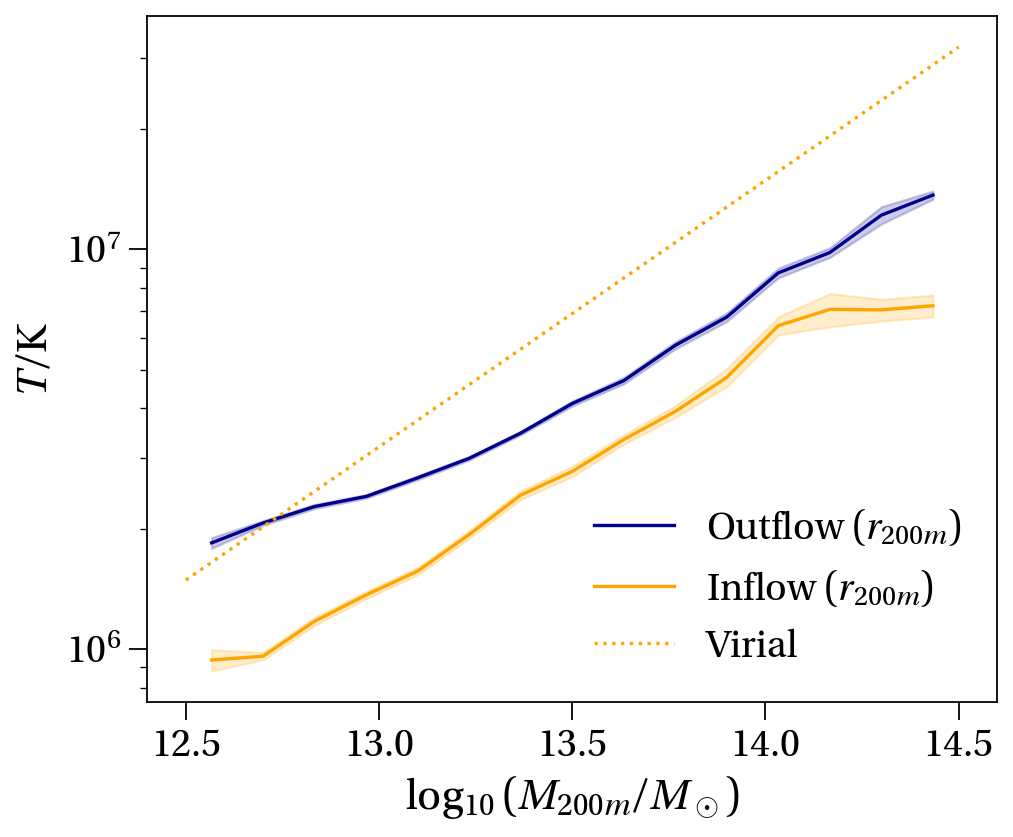

In [176]:

fa.make_binned_by_mass_plot(f'at(0, gas_temp_outflow_r200m_relative)', 
                                plot_kwargs={'color': 'darkblue'},
                                ts_name=ts, use_band=True,
                                weight_property_name=f'at(0, gas_mdot_outflow_r200m_relative)',
                                )
fa.make_binned_by_mass_plot(f'at(0, gas_temp_inflow_r200m_relative)', 
                                plot_kwargs={'color': 'orange'},
                                ts_name=ts, use_band=True,
                                weight_property_name=f'at(0, gas_mdot_inflow_r200m_relative)',
                                )

fa.plot_temp_guide() 
p.semilogy()
p.title("")
p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
p.ylabel(r"$T / \mathrm{K}$")
fa.legend(['Outflow ($r_{200m}$)', None, 'Inflow ($r_{200m}$)', None, 'Virial'], loc='lower right')

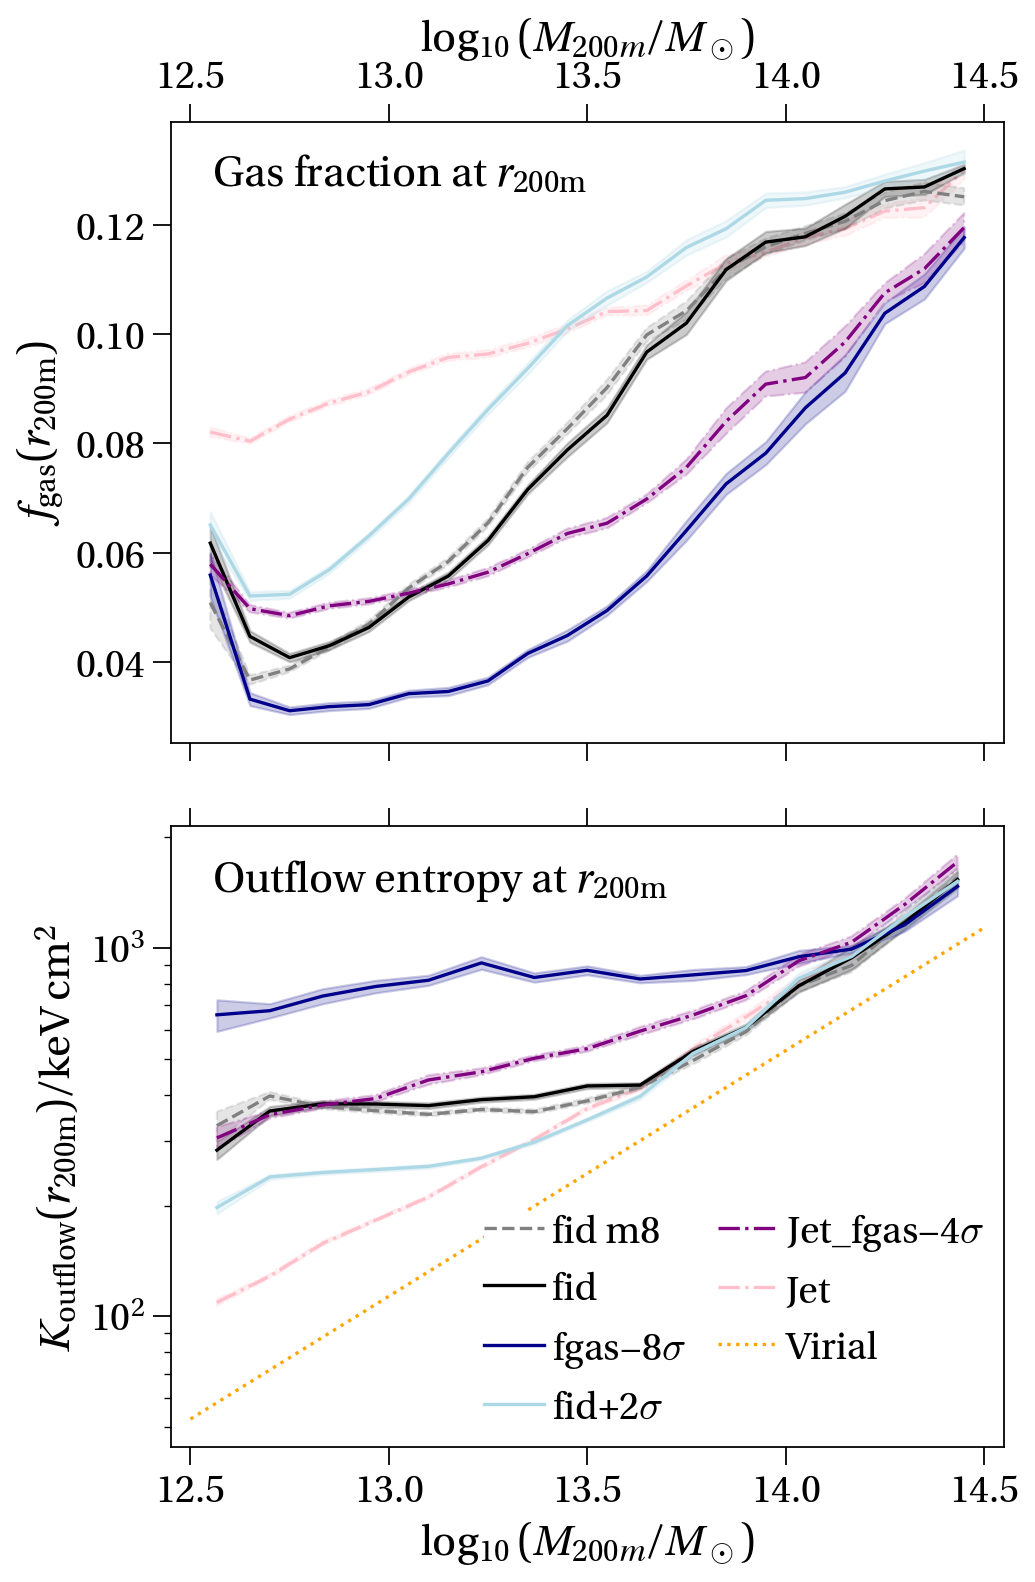

In [208]:
comparison_lines = [
    ('%720%FID%/%4.%', {'color': 'grey', 'linestyle': '--', 'label': 'fid m8'}),
    ('%360%FID%/%4.%', {'color': 'black', 'label': 'fid'}),
    ('%360%STRONGEST_AGN/%4.%', {'color': 'darkblue', 'label': r'fgas$-8\sigma$'}),
    ('%360%WEAK_AGN/%4.%', {'color': 'lightblue', 'label': r'fid$+2\sigma$'}),
    ('%360%JETS_STRONGER_AGN/%4.%', {'color': 'purple', 'linestyle': '-.', 'label': r'Jet_fgas$-4\sigma$'}),
    ('%360%JETS/%4.%', {'color': 'pink', 'linestyle': '-.', 'label': r'Jet', 'zorder': -1})
]

def entropy_comparison_plot(ts = '%360%FID%/%4.%', plot_kwargs=None):
    fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(0.0, gas_entropy_outflow_r200m_relative)', 
                                    plot_kwargs=plot_kwargs,
                                    ts_name=ts, use_band=True,
                                    weight_property_name=f'at(0.0, gas_mdot_outflow_r200m_relative)',
                                    )


def fgas_comparison_plot(ts = '%360%FID%/%4.%', plot_kwargs=None):
    fa.make_binned_by_mass_plot(f'at(0.0, gas_mass_enclosed_r200m_relative) / at(0.0, all_mass_enclosed_r200m_relative)', 
                                    plot_kwargs=plot_kwargs,
                                    ts_name=ts, use_band=True,
                                    num_bins=20
                                    )
    

p.figure(figsize=(6.9, 5.2*2))

p.subplot(211)
for ts, kwargs in comparison_lines:
    fgas_comparison_plot(ts, kwargs)
p.text(0.05, 0.95, "Gas fraction at $r_{\\rm 200m}$", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
p.ylabel(r"$f_{\rm gas}(r_{\rm 200m})$")
p.title("")
p.xlim(12.45, 14.55)
upper_axis()



p.subplot(212)
for ts, kwargs in comparison_lines:
    entropy_comparison_plot(ts, kwargs)
p.semilogy()
p.text(0.05, 0.95, "Outflow entropy at $r_{\\rm 200m}$", transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
p.ylabel(r"$K_{\rm outflow}(r_{\rm 200m}) / \mathrm{keV\,cm^2}$")
p.title("")
p.xlim(12.45, 14.55)
fa.plot_entropy_guide()

lower_axis()

p.legend(
    loc='lower right',
    ncol=2,
    columnspacing=0.8,
    handletextpad=0.2,
    handlelength=1.5,
    facecolor='white',
    framealpha=1.0,
    borderpad=0.0
)

p.tight_layout()

p.savefig("model_comparison.pdf", bbox_inches='tight')


### Getting the entropy gradient for the jet_fgas-4sig variant

Fitted power-law: log_10 0.570304 * at(0.0, gas_entropy_outflow_r200m_relative) = -0.241 + 0.220 * log_10 M200m()


[]

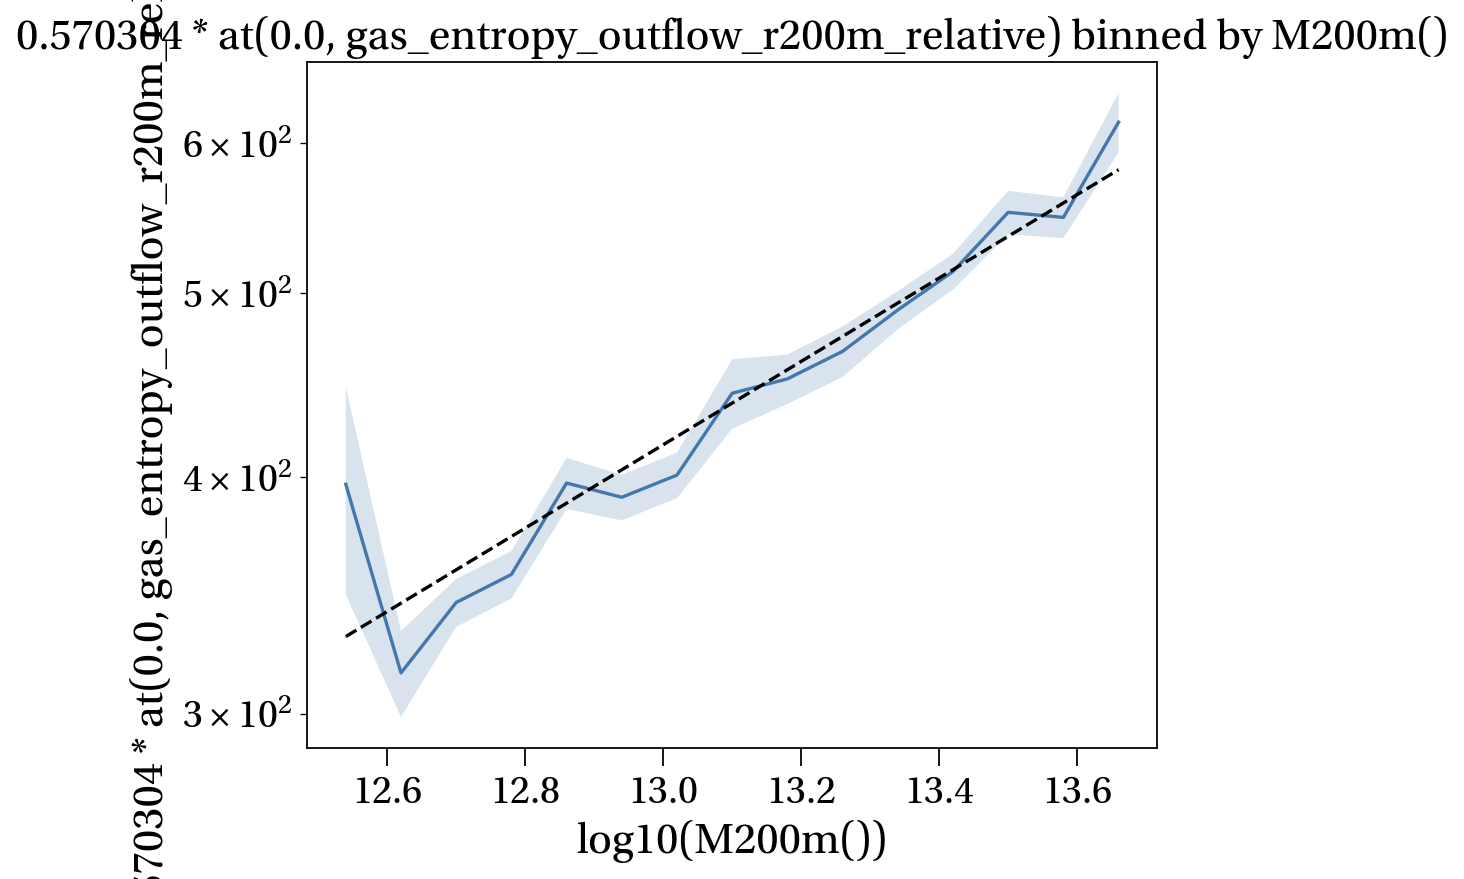

In [299]:
fa.make_binned_by_mass_plot(f'{internal_to_keV_cm2} * at(0.0, gas_entropy_outflow_r200m_relative)', 
                                    ts_name="%JETS_STRONG%/%4.%", use_band=True,
                                    weight_property_name=f'at(0.0, gas_mdot_outflow_r200m_relative)',
                                    bin_range=(12.5, 13.7),
                                    with_fit=True
                                    )
p.semilogy()

### Numerical values of the entropy floor for different variants

In [201]:
def get_entropy_floor(ts = '%720%/%8.%', mass_range=(12.9, 13.1)):
    """Get the entropy floor, assumed to be the measured outflow-weighted outflow entropy
    for the low mass halos in the sample"""

    mean, err, xs, _, _ = fa.get_stack(property_name = f'gas_entropy_outflow_r200m_relative', 
                 M_min = mass_range[0], M_max = mass_range[1],
                 timestep_name=ts, 
                 weight_by=f'gas_mdot_outflow_r200m_relative', use_log=False)
    
    virial_index = np.argmin(np.abs(xs)) # find log10(r200m) = 0
    return internal_to_keV_cm2 * mean[virial_index], internal_to_keV_cm2 *  err[virial_index]

    

In [202]:
get_entropy_floor('%720%FID%/%4.%') # m8 fiducial case

(np.float64(358.32711673211776), np.float64(5.229370328496532))

In [203]:

get_entropy_floor('%360%FID%/%4.%') # m9 fiducial case 

(np.float64(370.9954821159675), np.float64(6.145922345673526))

In [204]:
get_entropy_floor('%360%STRONGEST%/%4.%') # strong AGN feedback case

(np.float64(795.9444031785706), np.float64(31.986033863958657))

In [205]:
get_entropy_floor('%360%WEAK%/%4.%') # weak AGN feedback case 

(np.float64(250.71137723530384), np.float64(2.8406737368270707))

In [206]:
get_entropy_floor('%360%FIDUCIAL%/%8.%') # z=0 redshift scaling test

(np.float64(612.3016117352076), np.float64(13.227619751876151))

In [207]:
get_entropy_floor('%360%FIDUCIAL%/%1.%') # z=1 redshift scaling test

(np.float64(211.47960956701058), np.float64(3.3411526977070785))

# Letter entropy plot

In [194]:
def make_plot_at_radius(tsnum, property, at=1.0, relative=True, log=False, weight=False, median=False,
                        boxname=r"%360%FIDUCIAL", use_band=False, error_range='std', norm=1.0):
    
    if weight and median:
        raise ValueError("Cannot use both weighting and median in the same plot.")
    log_at = np.log10(at)
    suffix = "_r200m_relative" if relative else ""
    outflow_full_property_name = f'at({log_at}, {property}_outflow{suffix})'
    inflow_full_property_name = f'at({log_at}, {property}_inflow{suffix})'
    if log:
        outflow_full_property_name = f'log10({norm} * abs({outflow_full_property_name}))'
        inflow_full_property_name = f'log10({norm} * abs({inflow_full_property_name}))'
    else:
        outflow_full_property_name = f'{norm} * abs({outflow_full_property_name})'
        inflow_full_property_name = f'{norm} * abs({inflow_full_property_name})'
    fa.make_binned_by_mass_plot(outflow_full_property_name, 
                                plot_kwargs={'color': 'black', 'label': 'Outflow'},
                                ts_name=f"{boxname}/%{tsnum}.hdf5",
                                use_band=use_band, error_range=error_range,
                                weight_property_name=f'at({log_at}, gas_mdot_outflow{suffix})' if weight else 'median' if median else None)
    fa.make_binned_by_mass_plot(inflow_full_property_name, 
                                plot_kwargs={'color': 'orange', 'label': 'Inflow'},
                                ts_name=f"{boxname}/%{tsnum}.hdf5",
                                use_band=use_band, error_range=error_range,
                                weight_property_name=f'at({log_at}, gas_mdot_inflow{suffix})' if weight else 'median' if median else None,
                                x_offset = 0.02)
    p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
    location_label = f"at {at:.1f} $r_{{200m}}$" if relative else f"{at:.1f} Mpc"
    p.ylabel(rf"{property.replace('_', ' ').title()} at {location_label}")
    p.title("")

def make_virial_entropy_plot(tsnum, at=1.0, relative=True, boxname=r"%360%FIDUCIAL", 
                             use_band=False, error_range='std', weight=False, median=False):
    log_at = np.log10(at)
    internal_to_keV_cm2 = 0.570304
    make_plot_at_radius(tsnum, f'gas_entropy', at=at, relative=relative, 
                        boxname=boxname, use_band=use_band, error_range=error_range, weight=weight, median=median, norm=internal_to_keV_cm2)
    p.title("")

    z = db.get_timestep(f"{boxname}/%{tsnum}.hdf5").redshift
    K1 = (vs.entropy(10**12.5, z=z))
    K2 = (vs.entropy(10**14.5, z=z))

    p.plot([12.5, 14.5], [K1*internal_to_keV_cm2, K2*internal_to_keV_cm2], color='brown', linestyle='--', label='Virial')
    p.title(f"z={z:.1f}")
    p.legend(loc='lower right')
    p.semilogy()
    p.xticks([12.5, 13.0, 13.5, 14.0, 14.5], ['', '13.0', '', '14.0', ''])
    ax = p.gca()
    ax.xaxis.set_tick_params(which='major', length=8)
    for label, tick in zip(ax.get_xticklabels(), ax.xaxis.get_major_ticks()):
        if label.get_text() == '':
            tick.tick1line.set_markersize(4)
            tick.tick2line.set_markersize(4)

In [195]:
snapnum = 4

redshift = db.get_timestep(f'%720%/%{snapnum}.hdf5').redshift

v_entrop_kwargs = {'relative': True, 
                   'error_range': (16, 84), 
                   'weight': True,
                   'median': False,
                   'use_band': True}
ylim = (20., 3e3)
ylabel = r"$K/{\rm keV\,cm^2}$"



def make_panels_at_radius(vnum, vthis, at):
      def _add_panel_annotation(model_description):
            radius = f"{at:.1f} $r_{{200m}}$" if at != 1.0 else "$r_{200m}$"
            if vthis == 0:
                  text_to_render = model_description
                  text_to_render += "\n" + radius
            else:
                  text_to_render = radius

            p.text(0.05, 0.95, text_to_render, transform=p.gca().transAxes, verticalalignment='top', horizontalalignment='left')
            

      p.subplot(vnum, 4, vthis*4+1)

      make_virial_entropy_plot(snapnum, at=at, **v_entrop_kwargs)

      def _set_ylim():
            if at > 1.0:
                  p.ylim(ylim[0]*2, ylim[1]*2)
            else:
                  p.ylim(ylim)
      _set_ylim()
      p.ylabel(ylabel)
      p.title("")
      if vthis>0:
            fa.remove_existing_legend()
      _add_panel_annotation("Fiducial")

      p.subplot(vnum, 4, vthis*4+2)
      make_virial_entropy_plot(snapnum, at=at, **v_entrop_kwargs, boxname='%WEAK%')
      _set_ylim()
      p.ylabel("")
      p.title("")
      fa.remove_existing_legend()
      p.gca().set_yticks([])
      _add_panel_annotation(r"$f_{\rm gas} + 2 \sigma$")

      p.subplot(vnum, 4, vthis*4+3)
      make_virial_entropy_plot(snapnum, at=at, **v_entrop_kwargs, boxname='%STRONGEST%')
      _set_ylim()
      p.ylabel("")
      p.title("")
      fa.remove_existing_legend()
      p.gca().set_yticks([])
      _add_panel_annotation(r"$f_{\rm gas} - 8 \sigma$")

      p.subplot(vnum, 4, vthis*4+4)
      make_virial_entropy_plot(snapnum, at=at, **v_entrop_kwargs, boxname='%JETS_STR%')
      _set_ylim()
      p.ylabel(ylabel)
      p.title("")
      p.gca().yaxis.set_label_position('right')
      p.gca().yaxis.set_ticks_position('right')
      fa.remove_existing_legend()
      _add_panel_annotation(r"Jets $f_{\rm gas} - 4 \sigma$")

      p.subplots_adjust(hspace=0, wspace=0)
      

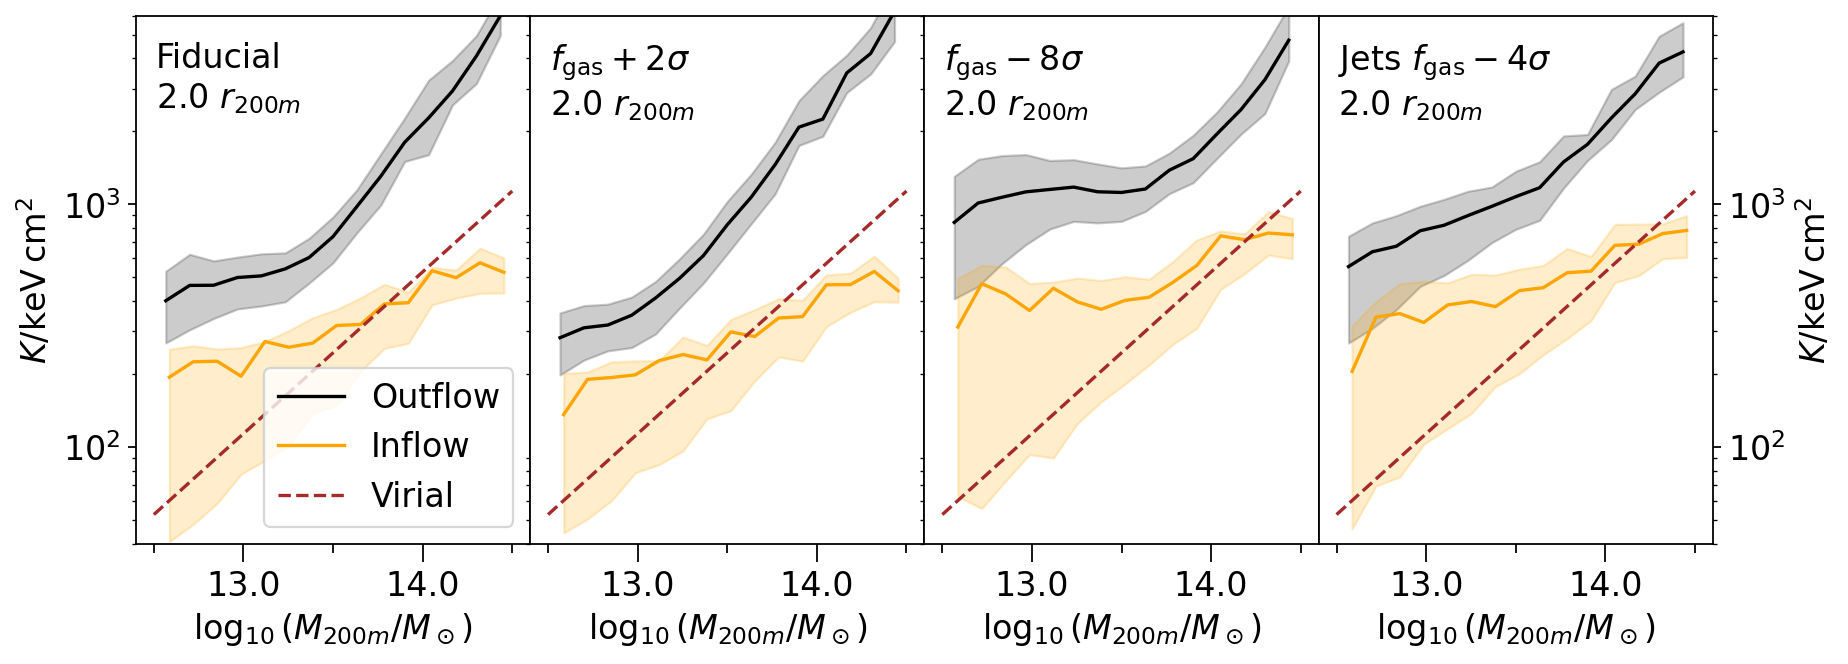

In [197]:
p.figure(figsize=(12.8,4.0))
# for letter - use default matplotlib styles with larger font
with p.rc_context(p.rcParamsDefault | {"font.size": 15}):
      make_panels_at_radius(1, 0, at=2.0)
      p.savefig('entropy_letter_fig_2r200.pdf', bbox_inches='tight')
      p.show()

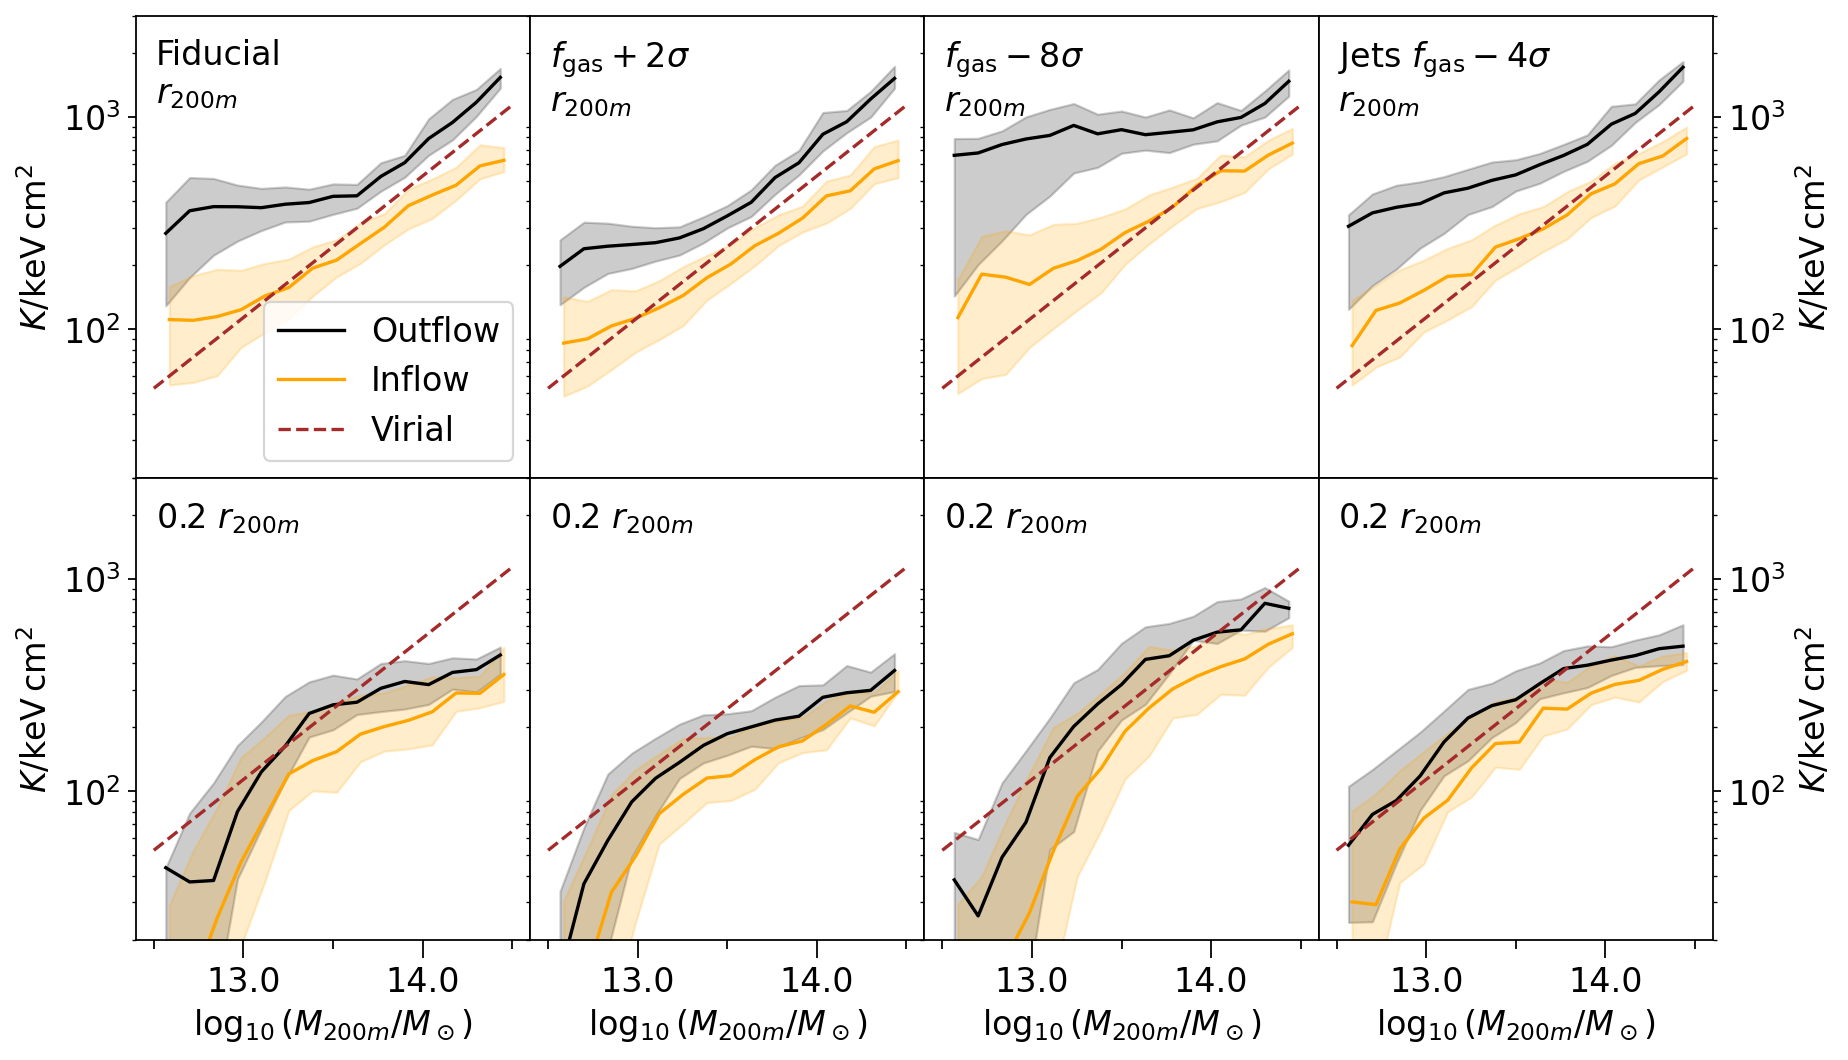

In [200]:
p.figure(figsize=(12.8,7.0))
# for letter - use default matplotlib styles with larger font
with p.rc_context(p.rcParamsDefault | {"font.size": 15}):
      make_panels_at_radius(2, 0, at=1.0)
      make_panels_at_radius(2, 1, at=0.2)
      p.savefig('entropy_letter_fig_tworow.pdf', bbox_inches='tight')
      p.show()

# Flow anisotropy plot

In [6]:
def four_panel_flow_plot(ts_top = "L0200N0360_HYDRO_FIDUCIAL/%4.hdf5", label_top='Fiducial',
                         ts_bottom = "L0200N0360_HYDRO_JETS_STRONGER_AGN/%4.hdf5", label_bottom='Jets fgas$-4\sigma$',
                         M_min=13.0, M_max=13.2):
    fig = p.figure(figsize=(12,9))

    p.subplot(221)
    fa.make_stacked_entropy_image_plot(ts_top,  M_min=M_min, M_max=M_max, axis='13', panel_label=label_top)
    p.gca().xaxis.tick_top()
    p.gca().xaxis.set_label_position('top')




    p.subplot(222)
    fa.make_stacked_entropy_image_plot(ts_top,  M_min=M_min, M_max=M_max, 
                                    axis='12', panel_label=label_top)
    p.gca().xaxis.tick_top()
    p.gca().xaxis.set_label_position('top')
    p.gca().yaxis.tick_right()
    p.gca().yaxis.set_label_position('right')


    p.subplot(223)
    fa.make_stacked_entropy_image_plot(ts_bottom, M_min=M_min, M_max=M_max, axis='13', panel_label=label_bottom)

    p.subplot(224)
    fa.make_stacked_entropy_image_plot(ts_bottom,  M_min=M_min, M_max=M_max, axis='12', panel_label=label_bottom)
    p.gca().yaxis.tick_right()
    p.gca().yaxis.set_label_position('right')

    from pynbody.plot import util
    import matplotlib
    Q = list(filter(lambda x: isinstance(x, matplotlib.quiver.Quiver), p.gca().get_children()))[-1]
    qk = util.PynbodyQuiverKey(Q, 1.35, 0.1, # <-- fragile - trial and error positioning outside axes!
                                250, "250 km/s",
                                color='k', labelcolor='k',
                                boxedgecolor='w', boxfacecolor='w')

    im = fig.axes[-1].images[-1]
    fig.subplots_adjust(left=0.0, right=9./12., bottom=0.0, top=1.0, wspace=0.0, hspace=0.0)
    cax = fig.add_axes([10.3/12., 0.25, 0.02, 0.5])
    fig.colorbar(im, cax=cax).set_label(r"$\log_{10} \left( K / {\rm keV\,cm^{2}} \right)$")


    fig.add_artist(qk)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vk/zg9_2k_512l3syhc8kdzkzwm0000gp/T/ipykernel_31583/818778292.py:2: SyntaxWarning: invalid escape sequence '\s'
  ts_bottom = "L0200N0360_HYDRO_JETS_STRONGER_AGN/%4.hdf5", label_bottom='Jets fgas$-4\sigma$',


In [213]:
Mtm, = db.get_timestep('%720%FID%/%4.%').calculate_all("M200m()")

In [217]:
((Mtm>10**13.0) & (Mtm<10**14.0)).sum()

np.int64(1065)

In [216]:
((Mtm>10**14)).sum()

np.int64(75)

/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:161: RuntimeWarning: invalid value encountered in log
  ln_p = np.log(p)
/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:161: RuntimeWarning: invalid value encountered in log
  ln_p = np.log(p)
/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:161: RuntimeWarning: invalid value encountered in log
  ln_p = np.log(p)
/Users/app/Science/flamingo/flamingo_tangos_properties/flamingo_analysis.py:161: RuntimeWarning: invalid value encountered in log
  ln_p = np.log(p)


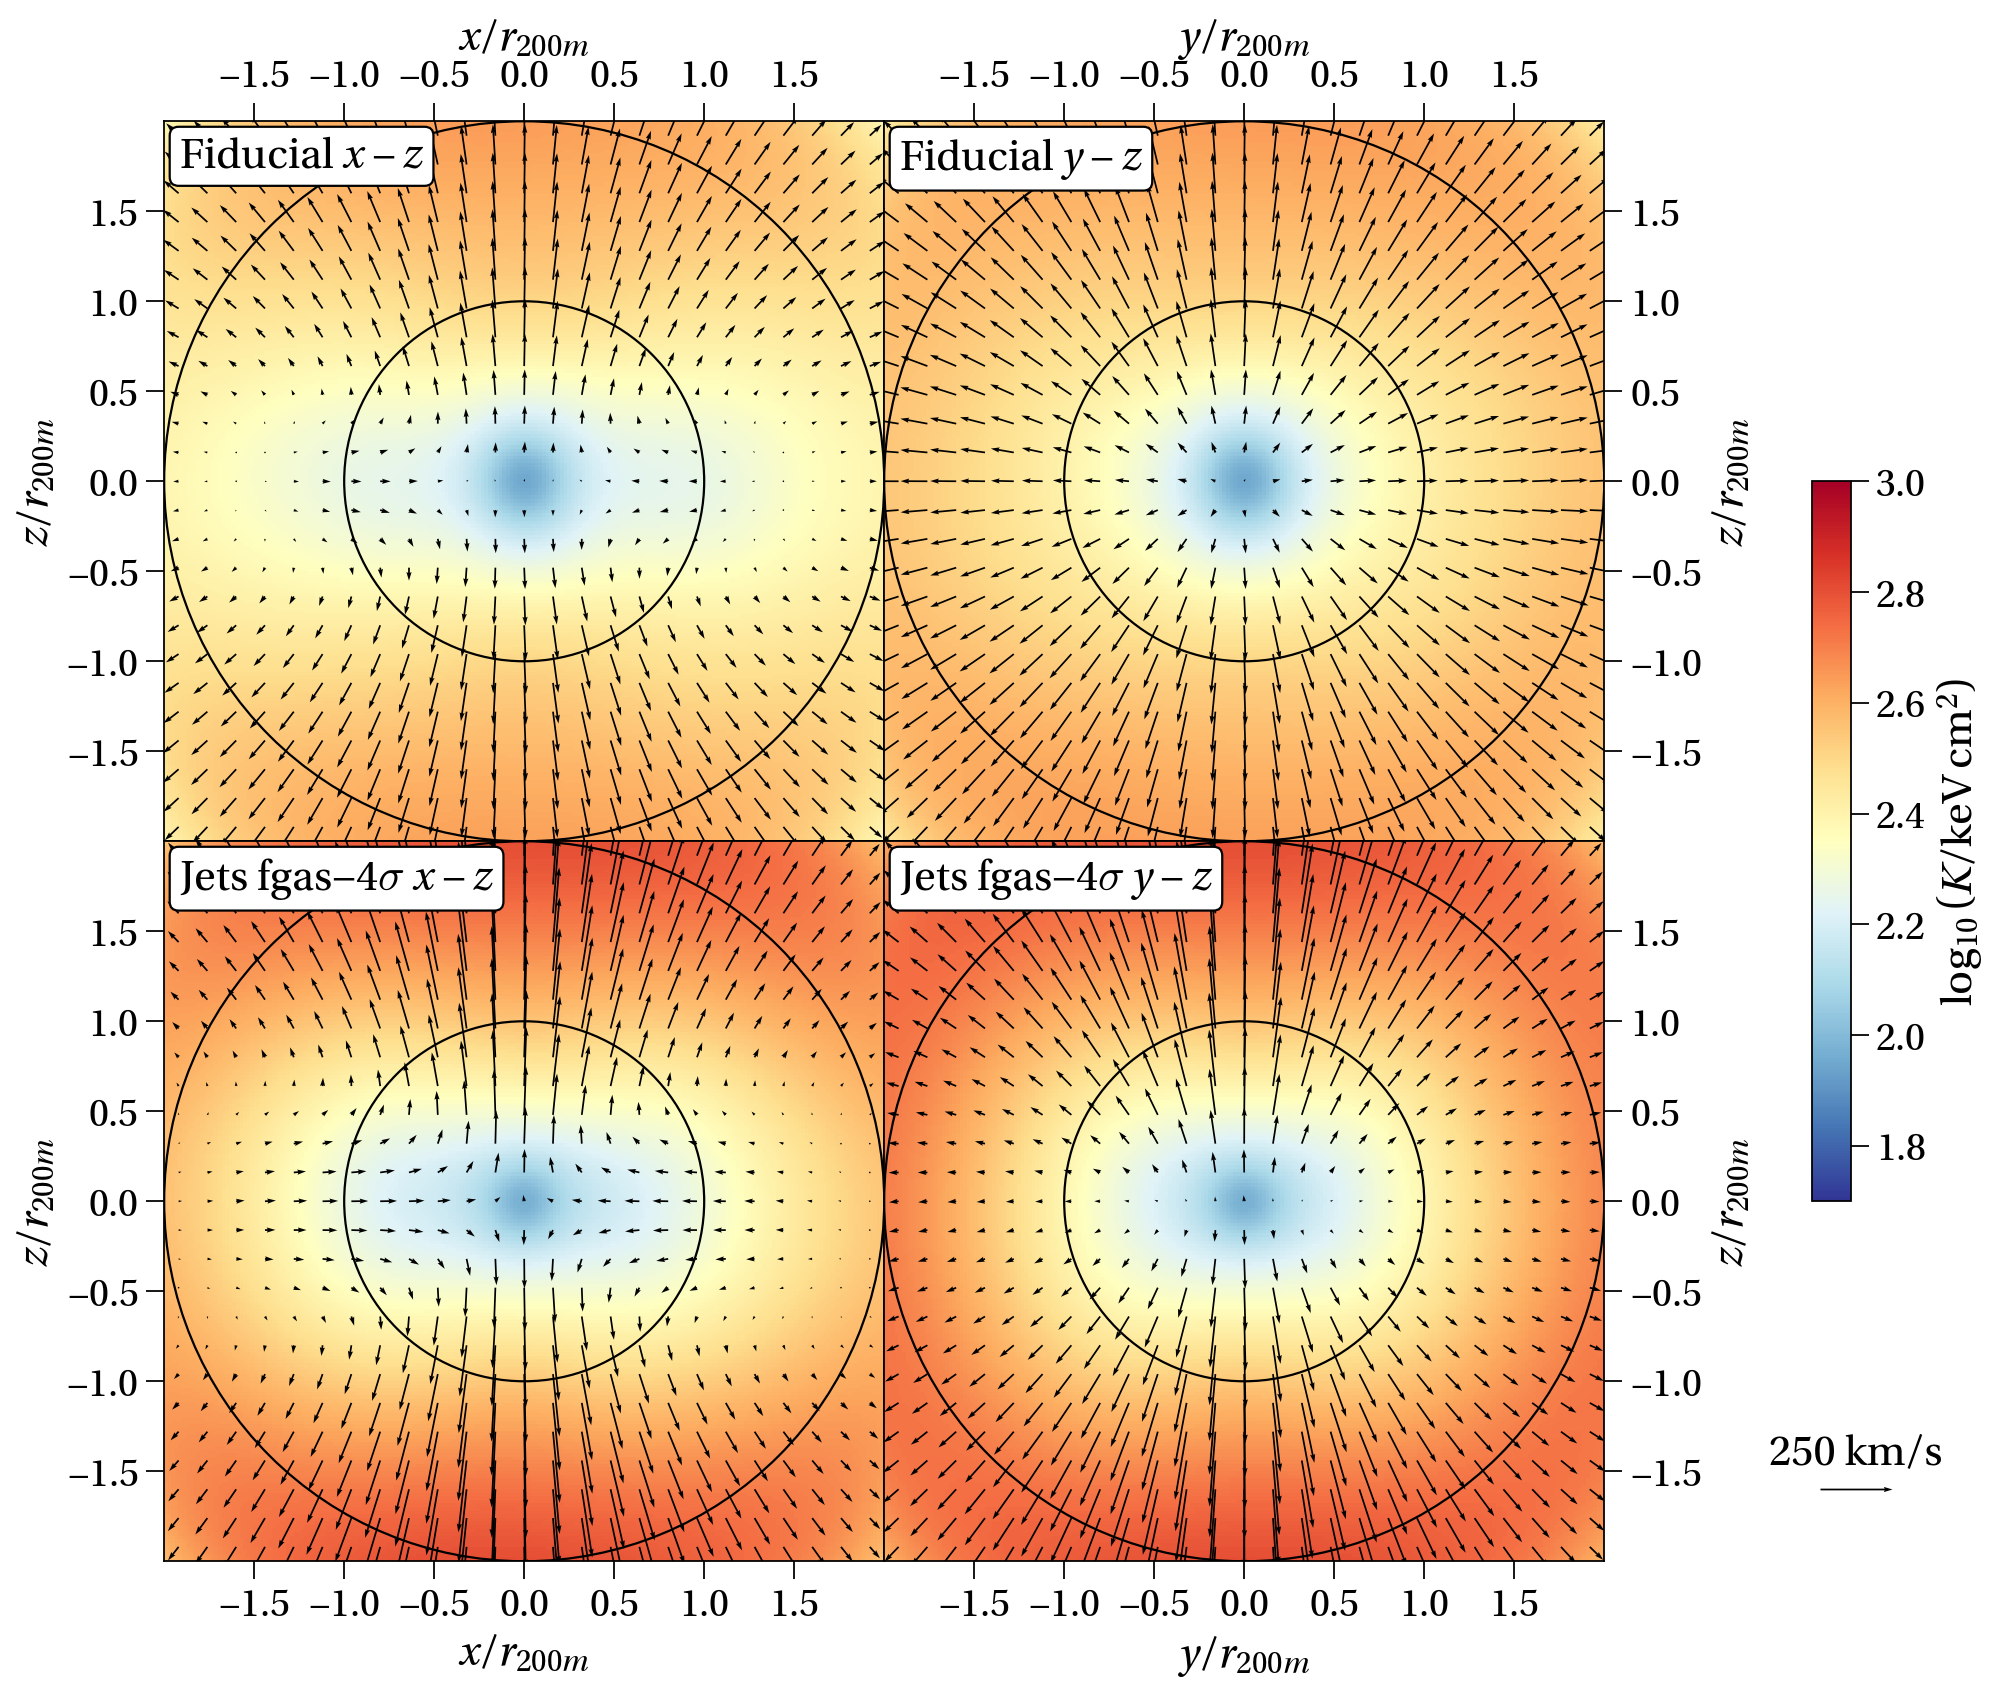

In [7]:
four_panel_flow_plot(M_min=12.5, M_max=13.0)
p.savefig("four_panel_flow_plot.pdf", bbox_inches='tight')

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vk/zg9_2k_512l3syhc8kdzkzwm0000gp/T/ipykernel_31583/1616369026.py:6: SyntaxWarning: invalid escape sequence '\s'
  fa.legend(['Fiducial', 'mean', None, 'Jets-4$\sigma$', 'mean'], loc='best')


vr mean range: 144.6 to 68.2 km/s
vr mean range: 251.0 to 21.5 km/s


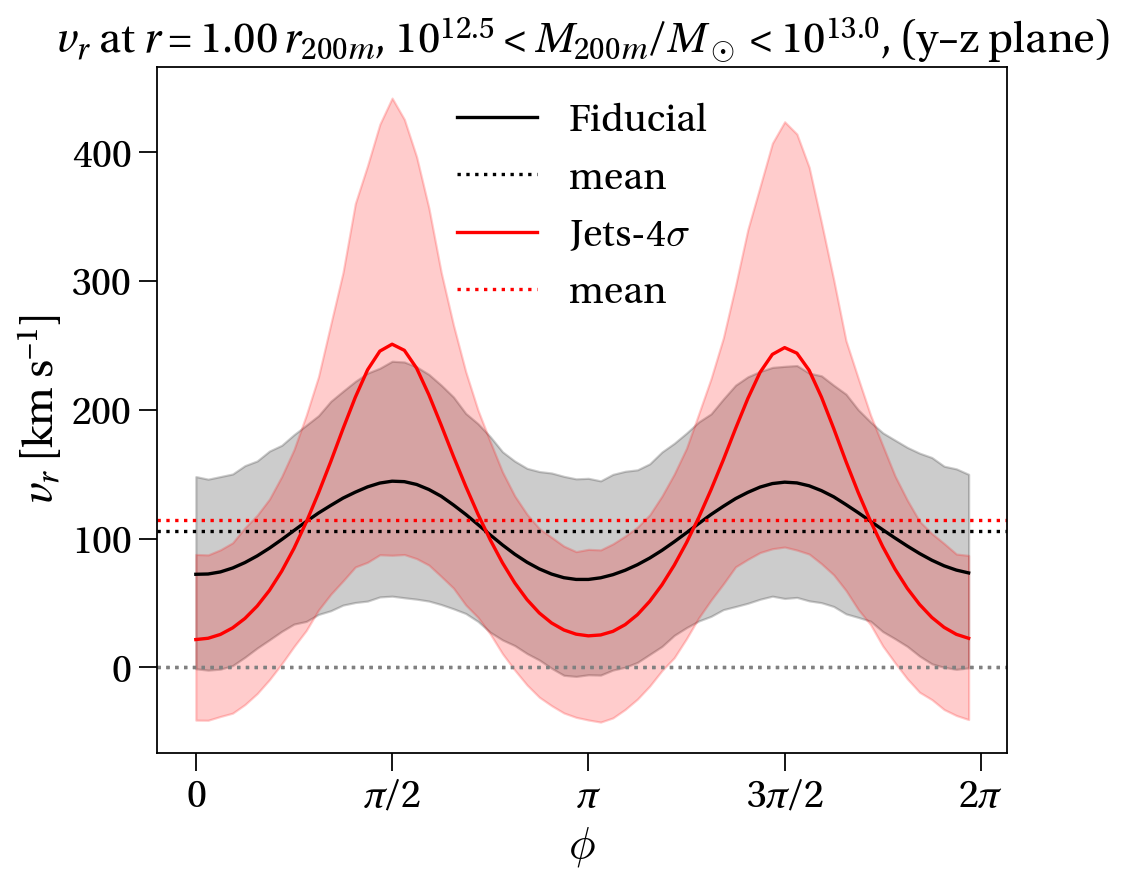

In [17]:
fa.make_stacked_vr_plot("L0200N0360_HYDRO_FIDUCIAL/%4.hdf5", M_min=12.5, M_max=13.0, axis='12', r_frac=1.0, with_mean_reference=True,
                        stack_mode=(16, 84), plot_kwargs={'color': 'black'})
fa.make_stacked_vr_plot("L0200N0360_HYDRO_JETS_STRONGER_AGN/%4.hdf5", M_min=12.5, M_max=13.0, axis='12', r_frac=1.0, with_mean_reference=True,
                        stack_mode=(16, 84), plot_kwargs={'color': 'red'})

fa.legend(['Fiducial', 'mean', None, 'Jets-4$\sigma$', 'mean'], loc='best')

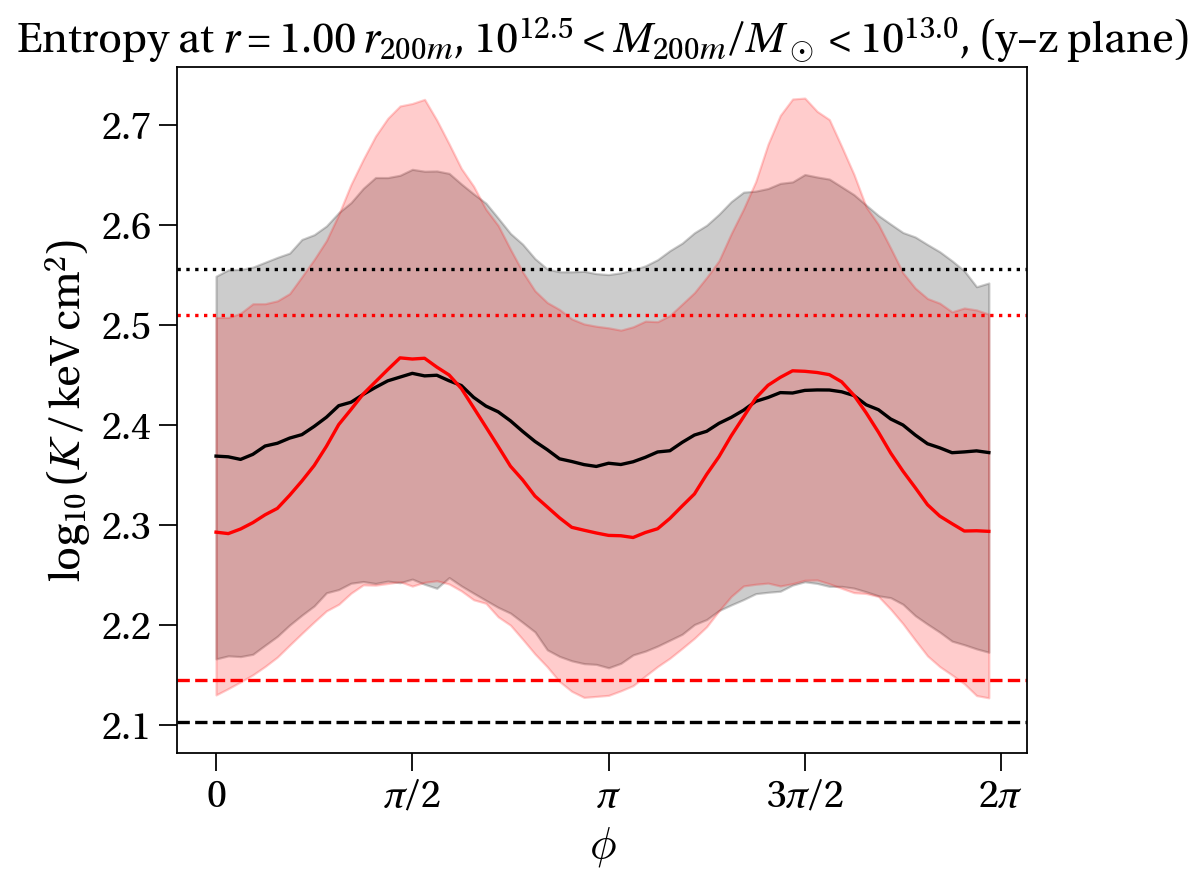

In [18]:
fa.make_stacked_entropy_angle_plot("L0200N0360_HYDRO_FIDUCIAL/%4.hdf5", M_min=12.5, M_max=13.0, axis='12', r_frac=1.0,
                                   stack_mode=(16, 84), show_reference_values=True, plot_kwargs={'color': 'black'})
fa.make_stacked_entropy_angle_plot("L0200N0360_HYDRO_JETS_STRONGER_AGN/%4.hdf5", M_min=12.5, M_max=13.0, axis='12', r_frac=1.0,
                                   stack_mode=(16, 84), show_reference_values=True, plot_kwargs={'color': 'red'})